# **1. Obtain a dataset and frame the predictive problem**


In [1]:
# load libraries and packages
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.stats.outliers_influence import variance_inflation_factor 

import warnings

from IPython.display import display

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score, mean_squared_log_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor


In [2]:
pd.set_option('display.max_columns', None)  # Show all columns in the output
# import dataset
df = pd.read_csv('UK-HPI-full-file-2025-12.csv')
df.head(20)

,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,DetachedPrice,DetachedIndex,Detached1m%Change,Detached12m%Change,SemiDetachedPrice,SemiDetachedIndex,SemiDetached1m%Change,SemiDetached12m%Change,TerracedPrice,TerracedIndex,Terraced1m%Change,Terraced12m%Change,FlatPrice,FlatIndex,Flat1m%Change,Flat12m%Change,CashPrice,CashIndex,Cash1m%Change,Cash12m%Change,CashSalesVolume,MortgagePrice,MortgageIndex,Mortgage1m%Change,Mortgage12m%Change,MortgageSalesVolume,FTBPrice,FTBIndex,FTB1m%Change,FTB12m%Change,FOOPrice,FOOIndex,FOO1m%Change,FOO12m%Change,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,130620.0,43.2,NaN,NaN,73972.0,40.9,NaN,NaN,58247.0,38.8,NaN,NaN,49322.0,45.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,129330.0,42.7,-1.0,NaN,74225.0,41.1,0.3,NaN,58669.0,39.1,0.7,NaN,50364.0,46.7,2.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,131585.0,43.5,1.7,NaN,76201.0,42.2,2.7,NaN,60399.0,40.2,2.9,NaN,51719.0,47.9,2.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,130454.0,43.1,-0.9,NaN,78082.0,43.2,2.5,NaN,62326.0,41.5,3.2,NaN,53143.0,49.2,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,132762.0,43.9,1.8,NaN,80340.0,44.5,2.9,NaN,64442.0,42.9,3.4,NaN,54678.0,50.7,2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0
5,01/06/2004,Aberdeenshire,S12000034,92485,44.9,NaN,3.3,NaN,NaN,525.0,136572.0,45.1,2.9,NaN,83191.0,46.0,3.5,NaN,66935.0,44.6,3.9,NaN,56901.0,52.7,4.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121174.0,43.7,3.2,NaN,164.0,89391.0,45.1,3.4,NaN,361.0
6,01/07/2004,Aberdeenshire,S12000034,96401,46.8,NaN,4.2,NaN,NaN,652.0,143558.0,47.4,5.1,NaN,86122.0,47.7,3.5,NaN,69178.0,46.1,3.4,NaN,58734.0,54.4,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125918.0,45.4,3.9,NaN,163.0,93285.0,47.0,4.4,NaN,489.0
7,01/08/2004,Aberdeenshire,S12000034,101315,49.2,NaN,5.1,NaN,NaN,512.0,151700.0,50.1,5.7,NaN,90186.0,49.9,4.7,NaN,72334.0,48.2,4.6,NaN,61241.0,56.7,4.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,131712.0,47.5,4.6,NaN,130.0,98214.0,49.5,5.3,NaN,382.0
8,01/09/2004,Aberdeenshire,S12000034,102220,49.7,NaN,0.9,NaN,NaN,497.0,153471.0,50.7,1.2,NaN,90814.0,50.3,0.7,NaN,72793.0,48.5,0.6,NaN,61552.0,57.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132519.0,47.8,0.6,NaN,142.0,99193.0,50.0,1.0,NaN,355.0
9,01/10/2004,Aberdeenshire,S12000034,102655,49.9,NaN,0.4,NaN,NaN,590.0,154137.0,50.9,0.4,NaN,91003.0,50.4,0.2,NaN,73013.0,48.6,0.3,NaN,62088.0,57.5,0.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133810.0,48.3,1.0,NaN,164.0,99411.0,50.1,0.2,NaN,426.0


# **2. Explore the data to gain insights**

In [3]:
sns.set_theme(style="whitegrid")

eda = df.copy()
eda["Date"] = pd.to_datetime(eda["Date"], dayfirst=True, errors="coerce")
# extract year
eda["Year"] = eda["Date"].dt.year
eda = eda.sort_values(["AreaCode", "Date"]).reset_index(drop=True)

## 2.1 Define target variable and column types

In [4]:
# define target and column types
target = "AveragePrice"
num_cols = eda.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in eda.columns if c not in num_cols]

print("Shape:", eda.shape)
print("Date range:", eda["Date"].min(), "to", eda["Date"].max())
print("Numeric cols:", len(num_cols), "| Non-numeric cols:", len(cat_cols))
print(eda.dtypes.to_frame(name="DataType"))

Shape: (149085, 55)
Date range: 1968-04-01 00:00:00 to 2025-12-01 00:00:00
Numeric cols: 52 | Non-numeric cols: 3
                              DataType
Date                    datetime64[ns]
RegionName                      object
AreaCode                        object
AveragePrice                     int64
Index                          float64
IndexSA                        float64
1m%Change                      float64
12m%Change                     float64
AveragePriceSA                 float64
SalesVolume                    float64
DetachedPrice                  float64
DetachedIndex                  float64
Detached1m%Change              float64
Detached12m%Change             float64
SemiDetachedPrice              float64
SemiDetachedIndex              float64
SemiDetached1m%Change          float64
SemiDetached12m%Change         float64
TerracedPrice                  float64
TerracedIndex                  float64
Terraced1m%Change              float64
Terraced12m%Change          

## 2.2 Check data quality

In [5]:
# data quality checks
print("\n--- Data quality checks ---")
print("Number of rows with missing dates:", eda["Date"].isna().sum())
print("Full-row duplicates:", eda.duplicated().sum())
print("Duplicate Date+AreaCode rows:", eda.duplicated(subset=["Date", "AreaCode"]).sum())
print("Unique RegionName:", eda["RegionName"].nunique())
print("Unique AreaCode:", eda["AreaCode"].nunique())

region_raw = eda["RegionName"].astype(str)
region_clean = region_raw.str.strip().str.lower()
print("RegionName unique (raw vs cleaned):", region_raw.nunique(), "vs", region_clean.nunique())


--- Data quality checks ---
Number of rows with missing dates: 0
Full-row duplicates: 0
Duplicate Date+AreaCode rows: 0
Unique RegionName: 405
Unique AreaCode: 405
RegionName unique (raw vs cleaned): 405 vs 405


In [6]:
# non-positive checks for fields where <=0 is suspicious
check_cols = [c for c in num_cols if any(k in c.lower() for k in ["price", "index", "volume"])]
non_pos = pd.Series({c: (eda[c] <= 0).sum() for c in check_cols}).sort_values(ascending=False)
print("\nTop non-positive counts:")
print(non_pos.head(15))


Top non-positive counts:
AveragePrice           0
CashSalesVolume        0
OldIndex               0
OldPrice               0
NewSalesVolume         0
NewIndex               0
NewPrice               0
FOOIndex               0
FOOPrice               0
FTBIndex               0
FTBPrice               0
MortgageSalesVolume    0
MortgageIndex          0
MortgagePrice          0
CashIndex              0
dtype: int64


## 2.3 Check data missingness


--- Missingness ---
                column  missing_pct
               IndexSA        96.48
        AveragePriceSA        96.48
        Cash12m%Change        58.98
         FOO12m%Change        58.98
    Mortgage12m%Change        58.98
         FTB12m%Change        58.72
       CashSalesVolume        56.36
   MortgageSalesVolume        56.35
          FOO1m%Change        56.09
     Mortgage1m%Change        56.09
         Cash1m%Change        56.09
         MortgagePrice        55.83
         MortgageIndex        55.83
             CashIndex        55.83
             CashPrice        55.83
              FOOPrice        55.83
              FOOIndex        55.83
          FTB1m%Change        55.82
              FTBPrice        55.56
              FTBIndex        55.56
         New12m%Change         8.15
         Old12m%Change         8.01
    Detached12m%Change         7.73
SemiDetached12m%Change         7.73
    Terraced12m%Change         7.66
        Flat12m%Change         7.48
       

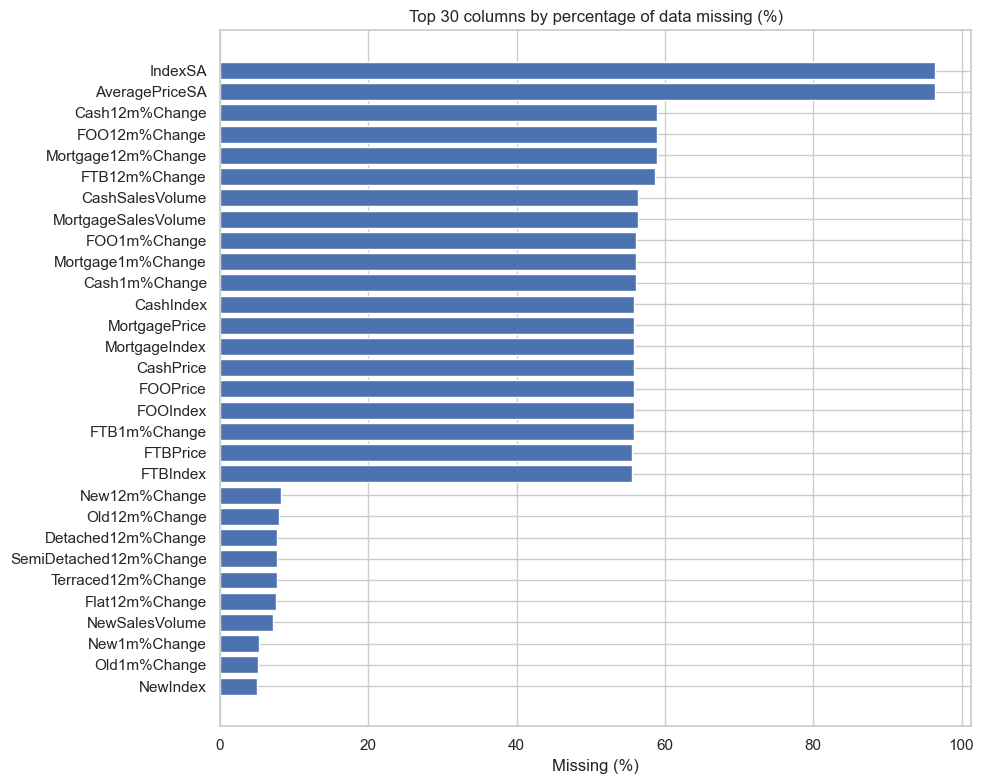

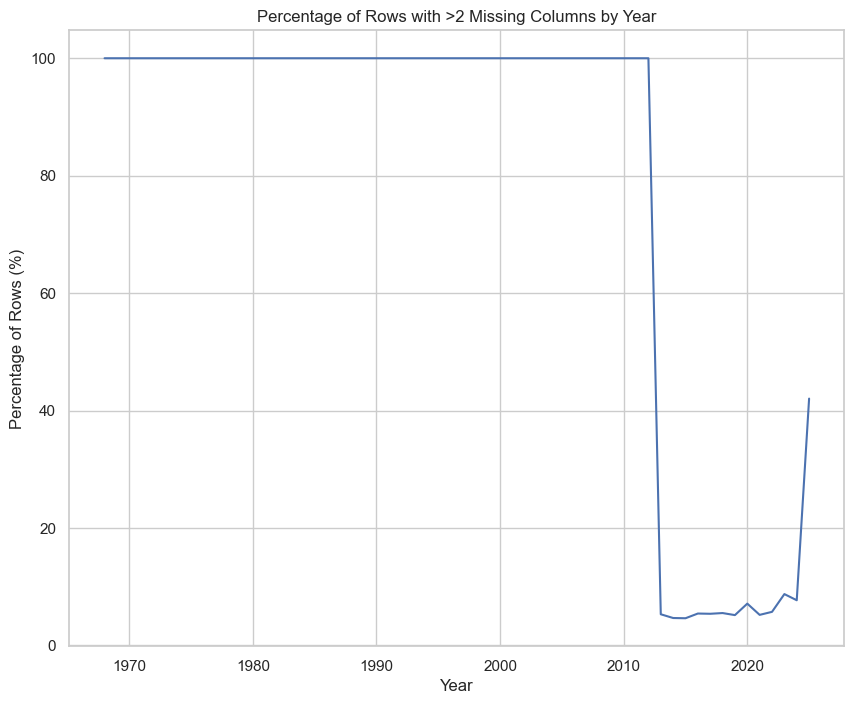

In [7]:
# missingness
missing_pct = (eda.isna().mean() * 100).sort_values(ascending=False).round(2)
missing_df = missing_pct.reset_index()
missing_df.columns = ["column", "missing_pct"]

print("\n--- Missingness ---")
print(missing_df.to_string(index=False))

plt.figure(figsize=(10, 8))
top_missing = missing_df.head(30).sort_values("missing_pct", ascending=True)
plt.barh(top_missing["column"], top_missing["missing_pct"])
plt.title("Top 30 columns by percentage of data missing (%)")
plt.xlabel("Missing (%)")
plt.tight_layout()
plt.show()

# count missing values per row
missing_count_per_row = eda.isna().sum(axis=1)
# condition: more than 2 missing columns
rows_many_missing = missing_count_per_row > 2
# group by year
missing_rows_per_year = rows_many_missing.groupby(eda["Year"]).sum()
total_rows_per_year = eda.groupby("Year").size()
missing_pct_yr = (missing_rows_per_year / total_rows_per_year * 100)
plt.figure(figsize=(10, 8))
plt.plot(missing_pct_yr.index, missing_pct_yr.values)
plt.xlabel("Year")
plt.ylabel("Percentage of Rows (%)")
plt.title("Percentage of Rows with >2 Missing Columns by Year")
plt.show()

## 2.4 Check target variable distributions and skewness

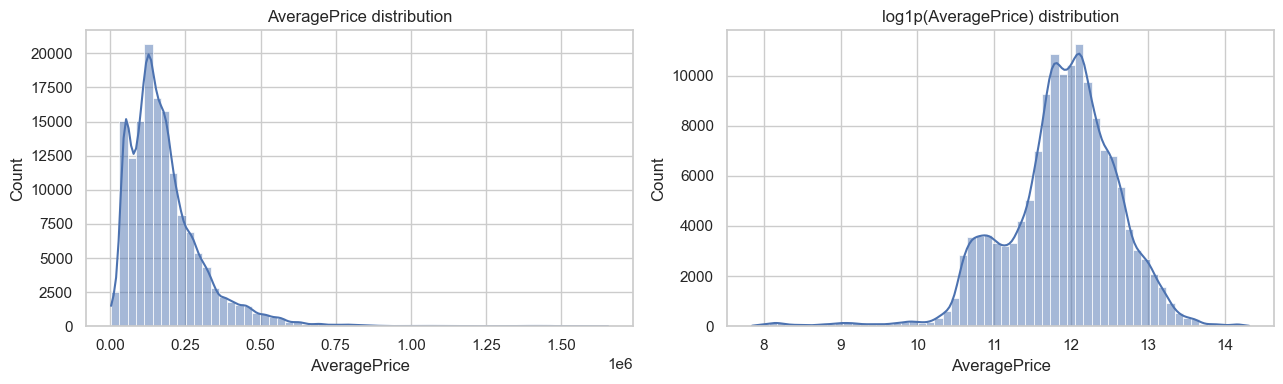

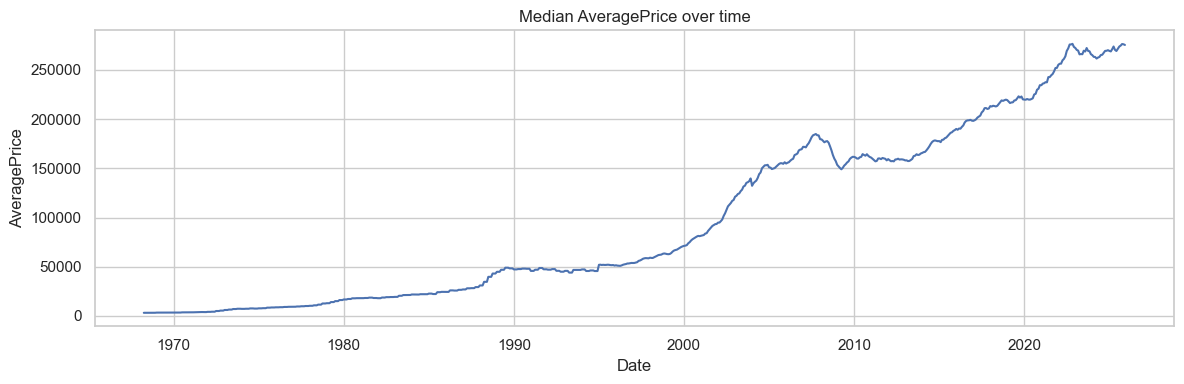

In [8]:
# distributions
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(eda[target].dropna(), bins=60, kde=True, ax=ax[0])
ax[0].set_title("AveragePrice distribution")

sns.histplot(np.log1p(eda[target].dropna()), bins=60, kde=True, ax=ax[1])
ax[1].set_title("log1p(AveragePrice) distribution")
plt.tight_layout()
plt.show()

monthly = eda.groupby("Date", as_index=False)[target].median()
plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly, x="Date", y=target)
plt.title("Median AveragePrice over time")
plt.tight_layout()
plt.show()

## 2.5 Check class imbalance at geographic and time dimensions


--- Region coverage imbalance ---
RegionName
Wales                       693
Scotland                    693
Yorkshire and The Humber    693
East Midlands               693
West Midlands Region        693
London                      693
South West                  693
England                     693
Northern Ireland            693
United Kingdom              693
South East                  405
East of England             405
North East                  405
Bradford                    372
Sheffield                   372
City of London              372
Barking and Dagenham        372
St Helens                   372
Liverpool                   372
Knowsley                    372
Name: count, dtype: int64
RegionName
North Ayrshire                         264
Scottish Borders                       264
Shetland Islands                       264
South Ayrshire                         264
South Lanarkshire                      264
Stirling                               264
City of Aberdeen   

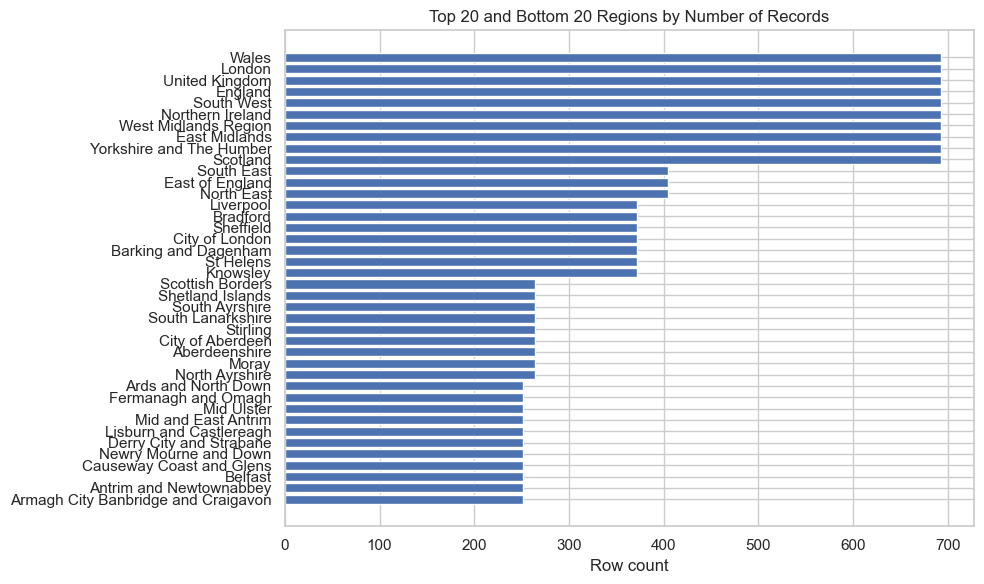

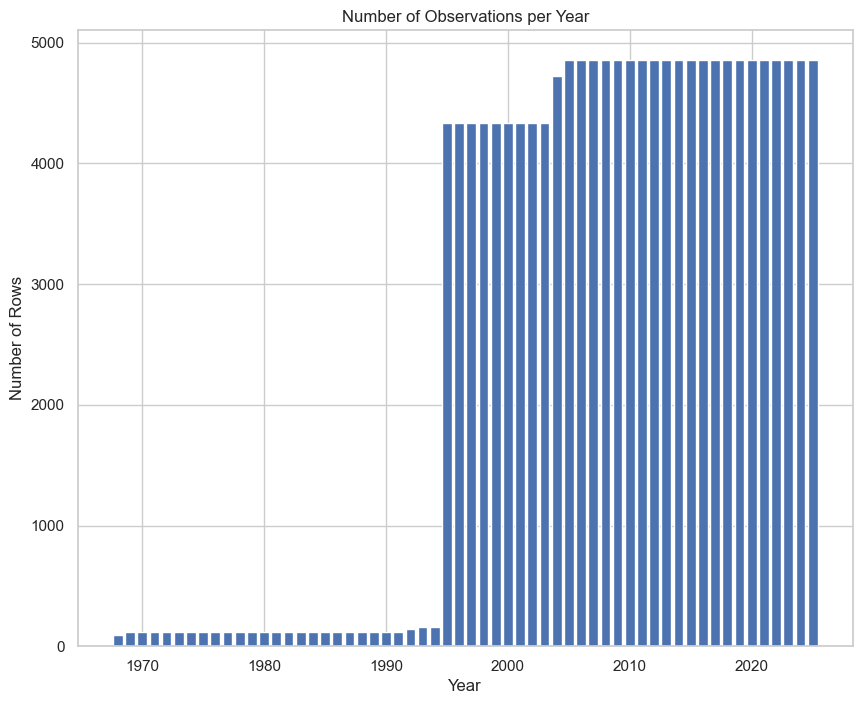

In [9]:
# class imbalance (coverage imbalance by region and year)
region_counts = eda["RegionName"].value_counts()
print("\n--- Region coverage imbalance ---")
print(region_counts.head(20))
print(region_counts.tail(20))
print("Max/min count ratio:", round(region_counts.max() / region_counts.min(), 2))

# select top 20 and least 20
top_20 = region_counts.head(20)
bottom_20 = region_counts.tail(20)

# combine them
selected_regions = pd.concat([top_20, bottom_20])

# sort for clean horizontal plot
selected_regions = selected_regions.sort_values(ascending=True)

# plot
plt.figure(figsize=(10, 6))
plt.barh(selected_regions.index, selected_regions.values)
plt.title("Top 20 and Bottom 20 Regions by Number of Records")
plt.xlabel("Row count")
plt.tight_layout()
plt.show()

# count rows per year
rows_per_year = eda.groupby("Year").size()

# number of rows per year
plt.figure(figsize=(10, 8))
plt.bar(rows_per_year.index, rows_per_year.values)
plt.xlabel("Year")
plt.ylabel("Number of Rows")
plt.title("Number of Observations per Year")
plt.show()

## 2.6 Check for outliers


--- Outlier percentage by column (top 20) ---
CashSalesVolume           13.82
SalesVolume               13.14
OldSalesVolume            13.12
MortgageSalesVolume       12.77
NewSalesVolume            12.15
DetachedPrice              7.15
SemiDetachedPrice          6.62
TerracedPrice              6.40
12m%Change                 5.98
New12m%Change              5.94
SemiDetached12m%Change     5.88
FlatPrice                  5.84
Terraced12m%Change         5.81
Old12m%Change              5.31
Flat12m%Change             5.28
OldPrice                   5.23
AveragePrice               5.18
Detached12m%Change         5.05
1m%Change                  4.62
FOOPrice                   4.50
dtype: float64


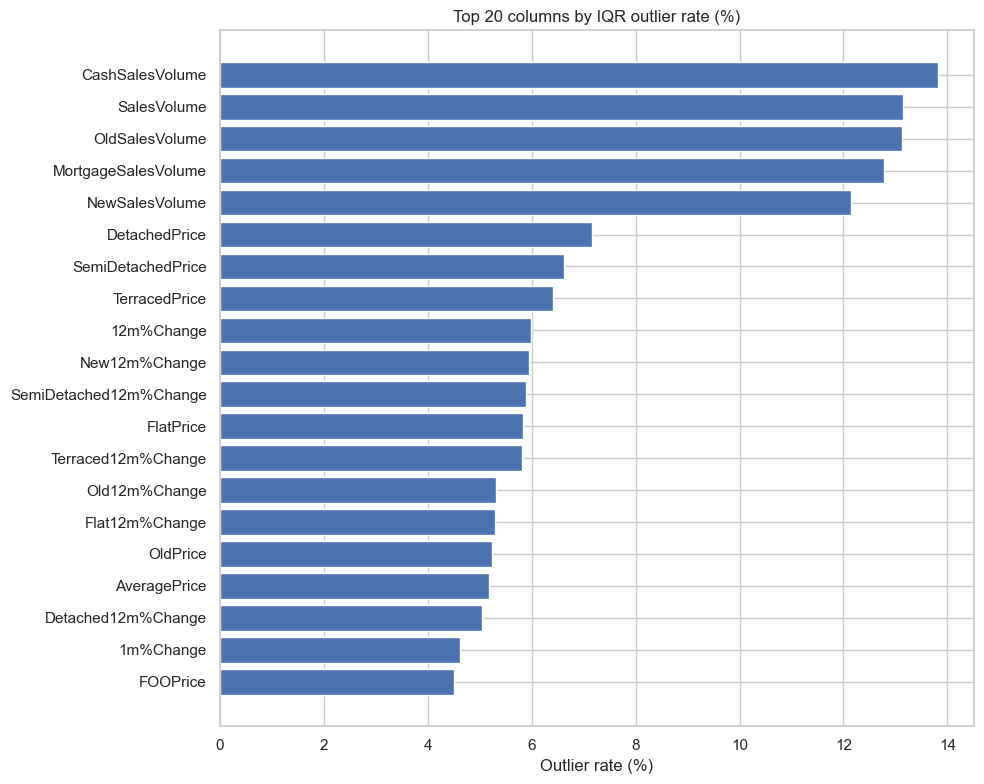

In [10]:
# define function for interquartile range (IQR) outlier check 
def iqr_outlier_pct(s):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean() * 100

outlier_pct = pd.Series({c: iqr_outlier_pct(eda[c]) for c in num_cols}).sort_values(ascending=False)
print("\n--- Outlier percentage by column (top 20) ---")
print(outlier_pct.head(20).round(2))

plt.figure(figsize=(10, 8))
top_out = outlier_pct.head(20).sort_values(ascending=True)
plt.barh(top_out.index, top_out.values)
plt.title("Top 20 columns by IQR outlier rate (%)")
plt.xlabel("Outlier rate (%)")
plt.tight_layout()
plt.show()

## 2.7 Check data leakage risk

In [11]:
# leakage risk scan 
corr_to_target = eda[num_cols].corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
print("\n--- Highest absolute correlation with target ---")
print(corr_to_target.head(20))

name_based_leak_risk = [c for c in num_cols if c != target and any(k in c.lower() for k in ["price", "index"])]
print("\nPotentially leaky same-period predictors (name-based):")
print(name_based_leak_risk[:30], "... total:", len(name_based_leak_risk))

high_corr_risk = corr_to_target[corr_to_target > 0.40]
print("\nHigh-correlation leakage candidates (|corr| > 0.40):")
print(high_corr_risk)



--- Highest absolute correlation with target ---
AveragePriceSA       0.999835
OldPrice             0.999642
MortgagePrice        0.999481
FOOPrice             0.997245
CashPrice            0.996786
FTBPrice             0.990115
FlatPrice            0.956436
DetachedPrice        0.925464
SemiDetachedPrice    0.910628
NewPrice             0.895271
TerracedPrice        0.888855
IndexSA              0.693421
Index                0.606520
NewIndex             0.605106
OldIndex             0.598178
TerracedIndex        0.587279
SemiDetachedIndex    0.585541
Year                 0.584636
DetachedIndex        0.581578
FlatIndex            0.574401
Name: AveragePrice, dtype: float64

Potentially leaky same-period predictors (name-based):
['Index', 'IndexSA', 'AveragePriceSA', 'DetachedPrice', 'DetachedIndex', 'SemiDetachedPrice', 'SemiDetachedIndex', 'TerracedPrice', 'TerracedIndex', 'FlatPrice', 'FlatIndex', 'CashPrice', 'CashIndex', 'MortgagePrice', 'MortgageIndex', 'FTBPrice', 'FTBIndex', 

# **3. Prepare the data**

In [12]:
# set target and horizon variables
TARGET = "AveragePrice"
HORIZON = 1  # predict next month

## 3.1 Standardise geographic regions

In [13]:
# remove high-level geographic regions
regions_remove = [
    "United Kingdom", "England", "Wales", "Scotland", "Northern Ireland", 
    "North West", "London", "North East", "Yorkshire and The Humber",
    "East Midlands", "West Midlands", "East of England", "South West","South East" 
]
df = df[~df["RegionName"].isin(regions_remove)]

## 3.2 Data validation

In [14]:
# create new dataset d as copy of df
d = df.copy()
d["Date"] = pd.to_datetime(d["Date"], dayfirst=True, errors="coerce")

validation = {
    "rows and columns": d.shape,
    "null_dates": d["Date"].isna().sum(),
    "dup_rows": d.duplicated().sum(),
    "dup_area_date": d.duplicated(["AreaCode", "Date"]).sum(),
    "missing_target": d[TARGET].isna().sum(),
    "non_positive_target": (d[TARGET] <= 0).sum(),
}
print(pd.Series(validation))

rows and columns       (140889, 54)
null_dates                        0
dup_rows                          0
dup_area_date                     0
missing_target                    0
non_positive_target               0
dtype: object


## 3.3 Data cleaning

In [15]:
# covert to string and remove whitespaces
d["RegionName"] = d["RegionName"].astype(str).str.strip()
d["AreaCode"] = d["AreaCode"].astype(str).str.strip()

# drop missing values in key columns
d = d.dropna(subset=["Date", "AreaCode", "RegionName", TARGET])

# drop duplicate values
d = d.drop_duplicates(subset=["AreaCode", "Date"], keep="last")

# sort values
d = d.sort_values(["AreaCode", "Date"]).reset_index(drop=True)

# Drop columns "IndexSA" and "AveragePriceSA" with >95% missing values 
sparse_cols = d.columns[d.isna().mean() > 0.95].tolist()
d = d.drop(columns=sparse_cols)

## 3.4 Leakage-safe feature engineering

In [16]:
# remove same-period target proxies (high leakage risk)
leaky_now = [
    c for c in d.columns
    if c != TARGET and any(k in c.lower() for k in ["averageprice", "price", "index"])
]

# temporal variables
d["month"] = d["Date"].dt.month
d["quarter"] = d["Date"].dt.quarter
d["year"] = d["Date"].dt.year
d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)

# create lag and rolling features
g = d.groupby("AreaCode", group_keys=False)
d["avg_lag1"] = g[TARGET].shift(1)
d["avg_lag3"] = g[TARGET].shift(3)
d["avg_lag12"] = g[TARGET].shift(12)
d["avg_roll3"] = g[TARGET].transform(lambda s: s.shift(1).rolling(3).mean())
d["avg_roll12"] = g[TARGET].transform(lambda s: s.shift(1).rolling(12).mean())

feature_cols = [
    "AreaCode", "RegionName",
    "year", "quarter", "month", "month_sin", "month_cos",
    "avg_lag1", "avg_lag3", "avg_lag12", "avg_roll3", "avg_roll12"
]

# shift target to create future prediction task
d["y"] = g[TARGET].shift(-HORIZON)

# create final dataset for modelling
model_df = d[["Date", "y"] + feature_cols].dropna(subset=["y"])

## 3.5 Check multicollinearity of selected features

In [17]:
# numeric predictors only
num_cols_vif = [
    "year", "quarter", "month", "month_sin", "month_cos",
    "avg_lag1", "avg_lag3", "avg_lag12", "avg_roll3", "avg_roll12"
]

# apply VIF
X_vif = model_df[num_cols_vif].copy()

# median impute + drop constant columns
X_vif = X_vif.fillna(X_vif.median(numeric_only=True))
const_cols = [c for c in X_vif.columns if X_vif[c].nunique() <= 1]
X_vif = X_vif.drop(columns=const_cols)

# compute VIF
vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif_df)

,feature,VIF
8,avg_roll3,7909.140279
6,avg_lag3,5648.428387
9,avg_roll12,1204.830990
5,avg_lag1,889.303106
7,avg_lag12,818.413072
1,quarter,118.865121
2,month,81.151720
0,year,19.715279
3,month_sin,2.950383
4,month_cos,1.148339


## 3.6 Address multicollinearity

Correlation of numeric features with target:
y            1.000000
avg_lag1     0.998794
avg_lag12    0.992163
year         0.570763
month_sin    0.022613
month_cos    0.003158
Name: y, dtype: float64


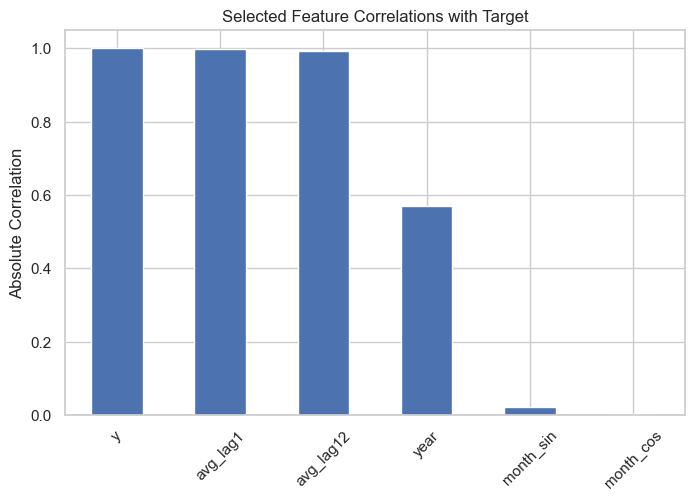

In [18]:
# further reduce features based on VIF 
feature_cols = [
    "AreaCode", "RegionName",
    "year", "month_sin", "month_cos",
    "avg_lag1", "avg_lag12"             # some engineered features removed due to high multicollinearity
]

d["y"] = g[TARGET].shift(-HORIZON)
model_df = d[["Date", "y"] + feature_cols].dropna(subset=["y"])

# Verify validity of features chosen as predictors
numeric_df = model_df.select_dtypes(include="number")

# correlation with target
corr_with_target = numeric_df.corr()["y"].abs().sort_values(ascending=False)

# show predictors
print("Correlation of numeric features with target:")
print(corr_with_target)

# plot
plt.figure(figsize=(8,5))
corr_with_target.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Selected Feature Correlations with Target")
plt.ylabel("Absolute Correlation")
plt.show()

## 3.7 Time-based data split

In [19]:
# time based 60-20-20 train-val-test split
model_df["Date"] = pd.to_datetime(model_df["Date"], errors="coerce")
model_df = model_df.dropna(subset=["Date", "y"]).sort_values("Date").reset_index(drop=True)

n=len(model_df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

# split model_df into train, validation and test sets
train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

# target and predictor features from split
X_train, y_train = train_df[feature_cols], train_df["y"]
X_val, y_val = val_df[feature_cols], val_df["y"]
X_test, y_test = test_df[feature_cols], test_df["y"]

#classify feature types
log_cols = ["avg_lag1", "avg_lag12"]
cat_cols = ["AreaCode", "RegionName"]
num_other_cols = [c for c in feature_cols if c not in log_cols + cat_cols]

# show split
print("Rows -> Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Date ranges:")
print("Train:", train_df["Date"].min().date(), "to", train_df["Date"].max().date())
print("Validation:", val_df["Date"].min().date(), "to", val_df["Date"].max().date())
print("Test :", test_df["Date"].min().date(), "to", test_df["Date"].max().date())


Rows -> Train: 84298 Val: 28100 Test: 28100
Date ranges:
Train: 1968-04-01 to 2013-12-01
Validation: 2013-12-01 to 2019-12-01
Test : 2019-12-01 to 2025-11-01


## 3.8 Reproducible preprocessing with transformers

In [20]:
# preprocessing predictor variables

# robust scaling for numeric values
# One-hot encoding for categorical variables
preprocess = ColumnTransformer(
    transformers=[
        # log-transform lag features 
        ("log_num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scaler", RobustScaler())
        ]), log_cols),

        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), num_other_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=10))
        ]), cat_cols),
    ]
)

## 3.9 Baseline model

In [21]:
# define baseline model pipeline
x_pipe = Pipeline([
    ("prep", preprocess),
    # linear Ridge as baseline model
    ("model", Ridge(alpha=10.0))
])

# pipeline for target variable
pipe = TransformedTargetRegressor(
    regressor=x_pipe,
    # log-transform target variable
    func=np.log1p,
    inverse_func=np.expm1
)

# train baseline model and predict for train and validation sets
pipe.fit(X_train, y_train)
pred_val = pipe.predict(X_val)
pred_tr = pipe.predict(X_train)

In [22]:
# Baseline metrics

# validation metrics
mae = mean_absolute_error(y_val, pred_val)
rmse = np.sqrt(mean_squared_error(y_val, pred_val))
rmsle = np.sqrt(mean_squared_log_error(y_val, pred_val))
r2 = r2_score(y_val, pred_val)

# training metrics
mae_tr = mean_absolute_error(y_train, pred_tr)
rmse_tr = np.sqrt(mean_squared_error(y_train, pred_tr))
rmsle_tr = np.sqrt(mean_squared_log_error(y_train, pred_tr))
r2_tr = r2_score(y_train, pred_tr)

# Produce tables
# validation set metrics
baseline_results = pd.DataFrame([{
    "Model": "Ridge (alpha=10.0)",
    "MAE": mae,
    "RMSE": rmse,
    "RMSLE": rmsle,
    "R2": r2
}])
display(baseline_results.round(4))

# training set metrics
baseline_results_tr = pd.DataFrame([{
    "Model": "Ridge (alpha=10.0)",
    "MAE": mae_tr,
    "RMSE": rmse_tr,
    "RMSLE": rmsle_tr,
    "R2": r2_tr
}])
display(baseline_results_tr.round(4))

,Model,MAE,RMSE,RMSLE,R2
0,Ridge (alpha=10.0),7116.8137,9964.1979,0.0381,0.9953


,Model,MAE,RMSE,RMSLE,R2
0,Ridge (alpha=10.0),3695.6396,6583.4876,0.0626,0.9938


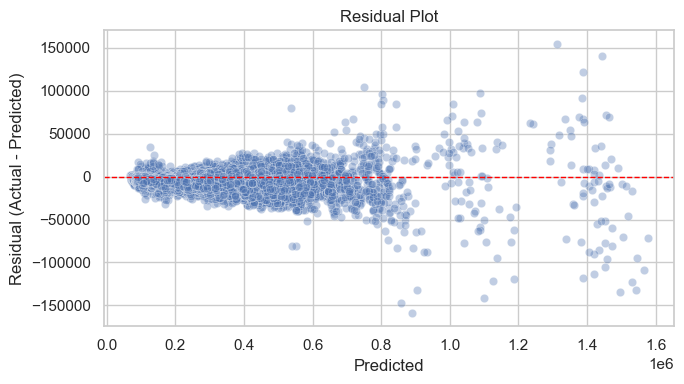

In [23]:
# residuals plot for baseline
residuals = y_val - pred_val

# residual plot: residuals vs predicted
plt.figure(figsize=(7, 4))
sns.scatterplot(x=pred_val, y=residuals, alpha=0.35)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


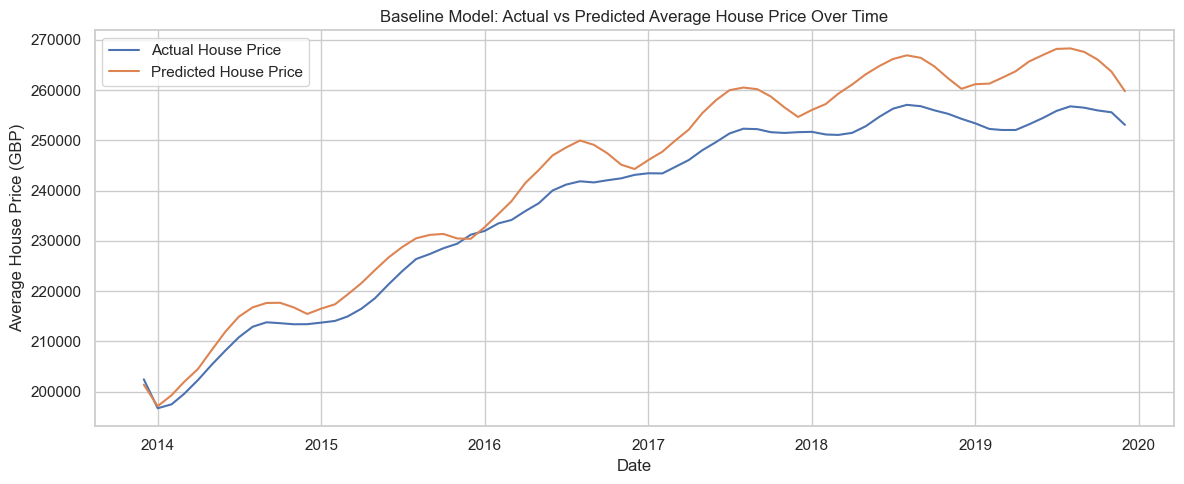

In [24]:
# Build plot dataframe
plot_df = pd.DataFrame({
    "Date": val_df["Date"].values,
    "ActualPrice": y_val.values,
    "PredictedPrice": pred_val
})

# For panel data (many regions), aggregate by date for a clean line chart
plot_daily = plot_df.groupby("Date", as_index=False)[["ActualPrice", "PredictedPrice"]].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(data=plot_daily, x="Date", y="ActualPrice", label="Actual House Price")
sns.lineplot(data=plot_daily, x="Date", y="PredictedPrice", label="Predicted House Price")
plt.title("Baseline Model: Actual vs Predicted Average House Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average House Price (GBP)")
plt.tight_layout()
plt.show()

## 3.10 Feature importance

Feature importance
avg_lag1      1.855161
avg_lag12     0.007888
AreaCode      0.002654
RegionName    0.002654
month_cos     0.000349
month_sin     0.000027
year         -0.000202
dtype: float64


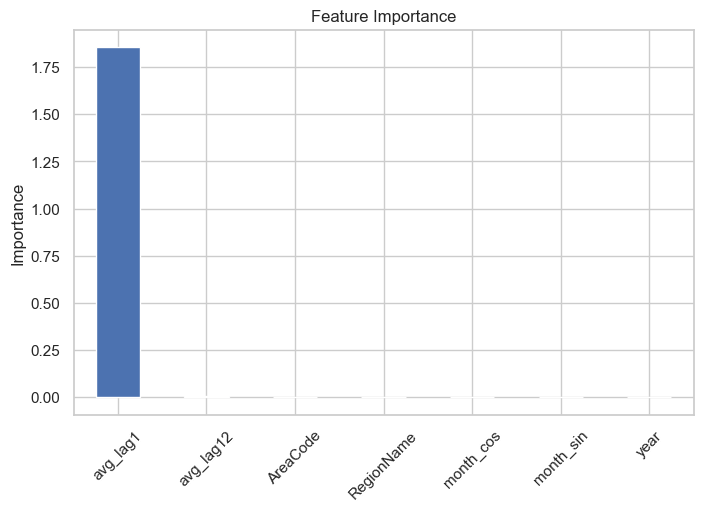

In [25]:
# Measure feature importance
result = permutation_importance(
    pipe,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
importance = pd.Series(
    result.importances_mean,
    index=X_val.columns
).sort_values(ascending=False)
print("Feature importance")
print(importance)
plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()


# **4. Explore different models and shortlist the best ones**

## 4.1 Split dataset

In [26]:
# input checks
data = model_df.copy()
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data = data.dropna(subset=["Date", "y"]).sort_values("Date").reset_index(drop=True)

# chronological split: 60% train, 20% validation, 20% test
n = len(data)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_df = data.iloc[:train_end].copy()
val_df = data.iloc[train_end:val_end].copy()
test_df = data.iloc[val_end:].copy()

X_train, y_train = train_df[feature_cols], train_df["y"]
X_val, y_val = val_df[feature_cols], val_df["y"]
X_test, y_test = test_df[feature_cols], test_df["y"]

# show split
print("Rows -> Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Date ranges:")
print("Train:", train_df["Date"].min().date(), "to", train_df["Date"].max().date())
print("Val  :", val_df["Date"].min().date(), "to", val_df["Date"].max().date())
print("Test :", test_df["Date"].min().date(), "to", test_df["Date"].max().date())



Rows -> Train: 84298 Val: 28100 Test: 28100
Date ranges:
Train: 1968-04-01 to 2013-12-01
Val  : 2013-12-01 to 2019-12-01
Test : 2019-12-01 to 2025-11-01


## 4.2 Preprocess predictors

In [27]:
# one-hot encoder function
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=10)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

In [28]:
# preprocess predictor variables
preprocess = ColumnTransformer(
    transformers=[
        ("log_num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scaler", RobustScaler())
        ]), log_cols),

        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), num_other_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=10))
        ]), cat_cols),
    ]
)

## 4.3 Candidate models

In [29]:
# create candidate models dictionary
models = {
    "GradientBoosting": Pipeline([
        ("prep", preprocess),
        ("model", GradientBoostingRegressor(
            n_estimators=500,           # faster
            learning_rate=0.05,
            max_depth=15,               # shallower trees = faster
            min_samples_leaf=10,
            min_samples_split=30,
            subsample=0.8,
            max_features="sqrt",
            random_state=42
        ))
    ]),
    "RandomForest": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=300,          # faster
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=1,
            max_features=0.5,
            bootstrap=True,
            max_samples=0.8,
            n_jobs=-1,
            random_state=42
        ))
    ]),
    "MLPRegressor": Pipeline([
        ("prep", preprocess),
        ("model", MLPRegressor(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            alpha=1e-3,
            learning_rate_init=1e-3,
            batch_size=128,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=5,
            max_iter=150,              # faster
            random_state=42
        ))
    ])
}
# initially used hyperparameters for random forest regressor, which gave FIGURE 13 in report
# "RandomForest": Pipeline([
#         ("prep", preprocess),
#         ("model", RandomForestRegressor(
#             n_estimators=500,          
#             max_depth=15,
#             min_samples_split=20,
#             min_samples_leaf=5,
#             max_features="sqrt",
#             bootstrap=True,
#             max_samples=0.7,
#             n_jobs=-1,
#             random_state=42
#         )) )]


## 4.4 Fit models and show results

In [30]:
# Define metrics
def reg_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "RMSLE": np.sqrt(mean_squared_log_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [31]:
# fit models and test on validation and training sets
fitted_models = {}
fitted_models2 = {}
pred_store = {}
pred_store2 = {}
rows = []
rows2 = []

for name, model_obj in models.items():
    x_pipe = Pipeline([
        ("model", model_obj)
    ])

    pipe = TransformedTargetRegressor(
        regressor=x_pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )

    # fit models
    pipe.fit(X_train, y_train)

    # get predictions for validation and training sets
    pred_val = pipe.predict(X_val)
    pred_train = pipe.predict(X_train)

    fitted_models[name] = pipe
    pred_store[name] = pred_val

    fitted_models2[name] = pipe
    pred_store2[name] = pred_train

    # validation metrics
    rows.append({
        "model": name,
        "MAE": mean_absolute_error(y_val, pred_val),
        "RMSE": np.sqrt(mean_squared_error(y_val, pred_val)),
        "RMSLE": np.sqrt(mean_squared_log_error(y_val, pred_val)),
        "R2": r2_score(y_val, pred_val)
    })

    # training metrics
    rows2.append({
        "model": name,
        "MAE": mean_absolute_error(y_train, pred_train),
        "RMSE": np.sqrt(mean_squared_error(y_train, pred_train)),
        "RMSLE": np.sqrt(mean_squared_log_error(y_train, pred_train)),
        "R2": r2_score(y_train, pred_train)
    })


In [34]:
# show results
results_val = pd.DataFrame(rows).sort_values("RMSLE").reset_index(drop=True)
print("Validation results for candidate models:")
display(results_val.round(4))

results_train = pd.DataFrame(rows2).sort_values("RMSLE").reset_index(drop=True)
print("Training results for candidate models:")
display(results_train.round(4))

Validation results for candidate models:


,model,MAE,RMSE,RMSLE,R2
0,RandomForest,5214.2016,13700.1412,0.0256,0.9912
1,MLPRegressor,24829.5669,63988.5499,0.1117,0.8072
2,GradientBoosting,25906.9444,50154.3305,0.1207,0.8815


Training results for candidate models:


,model,MAE,RMSE,RMSLE,R2
0,RandomForest,1182.8589,2235.8294,0.0162,0.9993
1,GradientBoosting,2850.0986,4601.2696,0.0329,0.9970
2,MLPRegressor,4813.2376,7489.1332,0.0558,0.9921


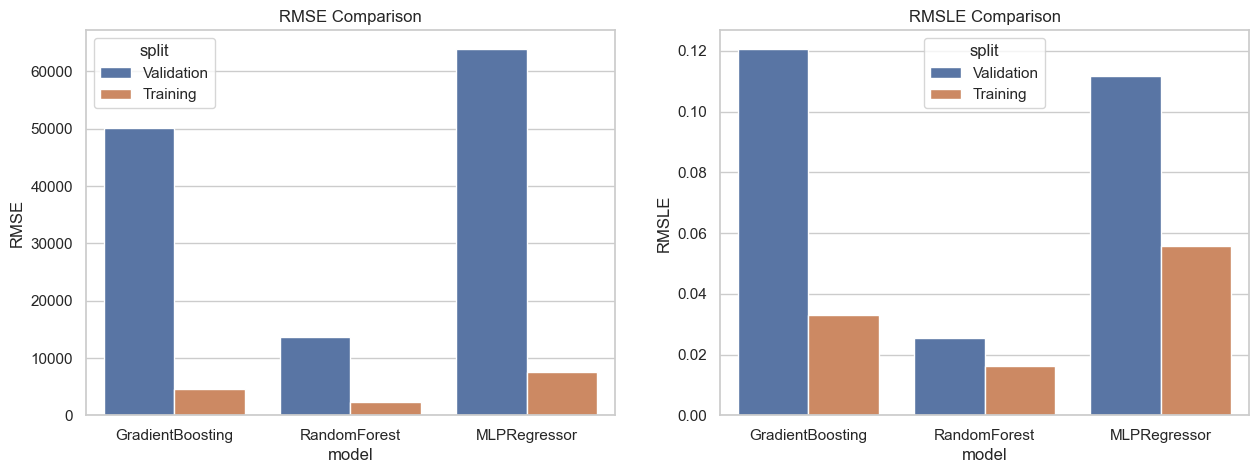

In [35]:
# plot RMSE and RMSLE metrics

all_results = pd.concat([
    pd.DataFrame(rows).assign(split="Validation"),
    pd.DataFrame(rows2).assign(split="Training")
])

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# Plot RMSE
sns.barplot(data=all_results, x="model", y="RMSE", hue="split", ax=ax[0])
ax[0].set_title("RMSE Comparison")
# Plot RMSLE
sns.barplot(data=all_results, x="model", y="RMSLE", hue="split", ax=ax[1])
ax[1].set_title("RMSLE Comparison")
plt.show()


# **5. Fine-tune and evaluate**

## 5.1 Fine-tuning

In [36]:
# define the Time Series Splitter
tscv = TimeSeriesSplit(n_splits=5)

# MLP Tuning Setup
mlp_params = {
    'regressor__model__hidden_layer_sizes': [(32,), (32, 16), (64, 32, 16)],
    'regressor__model__alpha': [0.001, 0.01, 0.1, 1.0],
    'regressor__model__learning_rate_init': [0.001, 0.0005]
}

mlp_pipe = TransformedTargetRegressor(
    regressor=Pipeline([
        ("prep", preprocess),
        ("model", MLPRegressor(
            early_stopping=True,
            max_iter=1000, 
            random_state=42))
    ]),
    func=np.log1p, inverse_func=np.expm1
)

In [37]:
# Gradient Boosting Tuning Setup
gb_space = {
    "model__n_estimators": [100, 150, 250, 400],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [10, 30, 60],
    "model__min_samples_leaf": [5, 10, 20],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__max_features": ["sqrt", "log2", None],
}

gb_pipe = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [38]:
# Random Forest Tuning Setup
rf_space = {
    "model__n_estimators": [120, 300, 500],
    "model__max_depth": [10, 25, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__max_samples": [0.6, 0.8, 1.0],
    "model__bootstrap": [True],
}

rf_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [39]:
# Ridge Tuning Setup
ridge_params = {
    'regressor__model__alpha': [0.1, 1, 10, 100, 200, 500, 1000]
}

ridge_pipe = TransformedTargetRegressor(
    regressor=Pipeline([
        ("prep", preprocess),
        ("model", Ridge())
    ]),
    func=np.log1p, inverse_func=np.expm1
)

In [ ]:
# Execute the Fine-Tuning
# RandomizedSearchCV for MLP as it's faster than GridSearch
mlp_search = RandomizedSearchCV(
    mlp_pipe, mlp_params, cv=tscv, scoring='neg_mean_squared_log_error', 
    n_iter=10,     # faster
    n_jobs=-1,
    random_state=42
)

gb_search = RandomizedSearchCV(
    estimator=gb_pipe,
    param_distributions=gb_space,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=tscv,     
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_space,
    n_iter=10,     # faster 
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

ridge_search = GridSearchCV(
    ridge_pipe, 
    ridge_params, 
    cv=tscv, 
    scoring='neg_mean_squared_log_error', 
    n_jobs=-1
)

In [41]:
# Fit on the combined Train + Validation set (the first 80% of data)
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

mlp_search.fit(X_train_val, y_train_val)
gb_search.fit(X_train_val, y_train_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('log_num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('log',
                                                                                                FunctionTransformer(feature_names_out='one-to-one',
                                                                                                                    func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                RobustScaler())]),
                                                                               ['avg_lag1',
                                                                                '...
                   param_distributions={'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__max_features': ['sqrt', 'log2',
                                                                None],
                                        'model__min_samples_leaf': [5, 10, 20],
                                        'model__min_samples_split': [10, 30,
                                                                     60],
                                        'model__n_estimators': [100, 150, 250,
                                                                400],
                                        'model__subsample': [0.7, 0.85, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [42]:
ridge_search.fit(X_train_val, y_train_val)
rf_search.fit(X_train_val, y_train_val)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x1064b5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('log_num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('log',
                                                                                                FunctionTransformer(feature_names_out='one-to-one',
                                                                                                                    func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                RobustScaler())]),
                                                                               ['avg_lag1',
                                                                                '...
                                                                    random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__bootstrap': [True],
                                        'model__max_depth': [10, 25, None],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.5],
                                        'model__max_samples': [0.6, 0.8, 1.0],
                                        'model__min_samples_leaf': [1, 5, 10],
                                        'model__min_samples_split': [2, 10],
                                        'model__n_estimators': [120, 300, 500]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [45]:
# print best hyperparameter configurations
def print_best_configs(search_obj, model_name):
    print(f"--- Final Hyperparameters for {model_name} ---")
    # access the internal regressor parameters
    best_params = search_obj.best_params_
    for param, value in best_params.items():
        # clean up the names for readability (removing 'regressor__model__')
        clean_name = param.split('__')[-1]
        print(f"{clean_name}: {value}")
    print("-" * 40)

print_best_configs(mlp_search, "Fine-Tuned MLP")
print_best_configs(gb_search, "Fine-Tuned Gradient Boosting")
print_best_configs(ridge_search, "Fine-Tuned Ridge")
print_best_configs(rf_search, "Fine-Tuned Random Forest")

--- Final Hyperparameters for Fine-Tuned MLP ---
learning_rate_init: 0.001
hidden_layer_sizes: (32,)
alpha: 1.0
----------------------------------------
--- Final Hyperparameters for Fine-Tuned Gradient Boosting ---
subsample: 0.85
n_estimators: 100
min_samples_split: 30
min_samples_leaf: 5
max_features: None
max_depth: 2
learning_rate: 0.1
----------------------------------------
--- Final Hyperparameters for Fine-Tuned Ridge ---
alpha: 100
----------------------------------------
--- Final Hyperparameters for Fine-Tuned Random Forest ---
n_estimators: 120
min_samples_split: 10
min_samples_leaf: 10
max_samples: 0.8
max_features: 0.5
max_depth: None
bootstrap: True
----------------------------------------


In [51]:
# Generate predictions using the best estimators
mlp_val_preds = mlp_search.best_estimator_.predict(X_val)
ridge_val_preds = ridge_search.best_estimator_.predict(X_val)
gb_val_preds = gb_search.best_estimator_.predict(X_val)
rf_val_preds = rf_search.best_estimator_.predict(X_val)

# Create results
def calculate_metrics(model, X, y, name):
    preds = model.predict(X)
    return {
        "Model": name,
        "MAE": mean_absolute_error(y, preds),
        "RMSE": np.sqrt(mean_squared_error(y, preds)),
        "RMSLE": np.sqrt(mean_squared_log_error(y, preds)),
        "MAPE": mean_absolute_percentage_error(y, preds),
        "R2": r2_score(y, preds)
    }

# Lists to store the row data
train_rows = []
val_rows = []

# Define your best estimators from the search objects
best_models = [
    (mlp_search.best_estimator_, "Fine-Tuned MLP"),
    (ridge_search.best_estimator_, "Fine-Tuned Ridge"),
    (gb_search.best_estimator_, "Fine-Tuned Gradient Boosting"),
    (rf_search.best_estimator_, "Fine-Tuned Random Forest")
]

for model_obj, name in best_models:
    # 1. Calculate Training Metrics
    train_rows.append(calculate_metrics(model_obj, X_train, y_train, name))
    
    # 2. Calculate Validation Metrics
    val_rows.append(calculate_metrics(model_obj, X_val, y_val, name))



## 5.2 Evaluate results

In [52]:
# metrics tables

# Table 1: Training Performance (How well the model learned the history)
train_results = pd.DataFrame(train_rows).sort_values("RMSLE").reset_index(drop=True)
print("TABLE 1: TRAINING SET PERFORMANCE (2004 - 2016 approx)")
display(train_results.round(4))

print("\n" + "-"*50 + "\n")

# Table 2: Validation Performance (How well the model predicts the 'future')
val_results = pd.DataFrame(val_rows).sort_values("RMSLE").reset_index(drop=True)
print("TABLE 2: VALIDATION SET PERFORMANCE (2017 - 2020 approx)")
display(val_results.round(4))

TABLE 1: TRAINING SET PERFORMANCE (2004 - 2016 approx)


,Model,MAE,RMSE,RMSLE,MAPE,R2
0,Fine-Tuned Random Forest,2211.8108,4013.6552,0.0375,0.0179,0.9977
1,Fine-Tuned Gradient Boosting,3378.4012,5825.0613,0.0658,0.0311,0.9952
2,Fine-Tuned Ridge,3438.4082,7144.8693,0.0695,0.0296,0.9928
3,Fine-Tuned MLP,3926.1357,7547.2684,0.0733,0.0341,0.9919



--------------------------------------------------

TABLE 2: VALIDATION SET PERFORMANCE (2017 - 2020 approx)


,Model,MAE,RMSE,RMSLE,MAPE,R2
0,Fine-Tuned Random Forest,2940.5241,5699.5417,0.0167,0.0119,0.9985
1,Fine-Tuned Ridge,4065.2758,7457.1610,0.0225,0.0169,0.9974
2,Fine-Tuned Gradient Boosting,4255.6080,7018.9451,0.0243,0.0182,0.9977
3,Fine-Tuned MLP,5318.8236,9099.0265,0.0299,0.0225,0.9961


/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/4205763563.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSLE", palette="viridis")


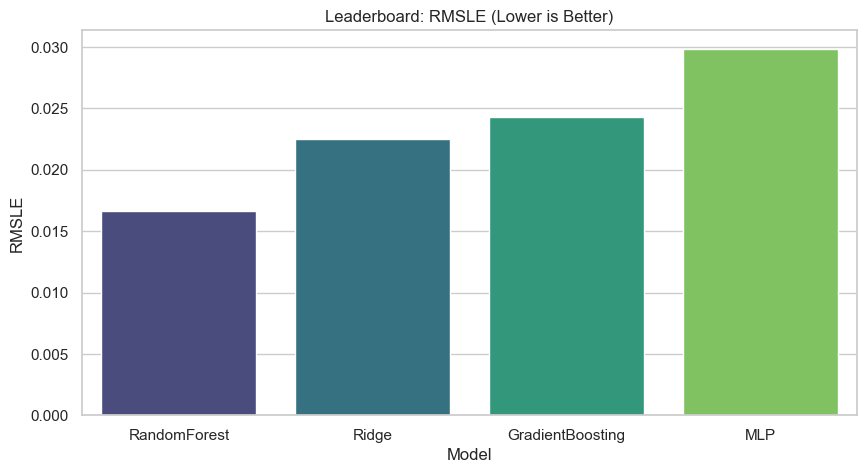

/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/4205763563.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", palette="viridis")


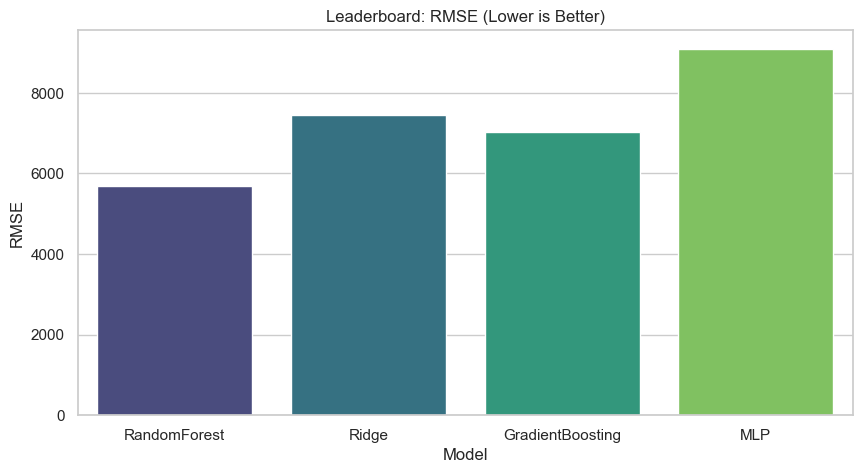

In [56]:
# Plot graphs
val_rows = []
for name, pred in [("MLP", mlp_val_preds), ("Ridge", ridge_val_preds), ("GradientBoosting", gb_val_preds), ("RandomForest", rf_val_preds)]:
    val_rows.append({
        "Model": name,
        "RMSLE": np.sqrt(mean_squared_log_error(y_val, pred)),
        "RMSE": np.sqrt(mean_squared_error(y_val, pred)),
        "MAE": mean_absolute_error(y_val, pred)
    })

results_df = pd.DataFrame(val_rows).sort_values("RMSLE")

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="RMSLE", palette="viridis")
plt.title("Leaderboard: RMSLE (Lower is Better)")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="RMSE", palette="viridis")
plt.title("Leaderboard: RMSE (Lower is Better)")
plt.show()

In [73]:
def robust_evaluate(y_true, y_pred, model_name):
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    metrics = {
        "Model": model_name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "RMSLE": np.sqrt(mean_squared_log_error(y_true, y_pred)),
    }
    return pd.DataFrame([metrics])

/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

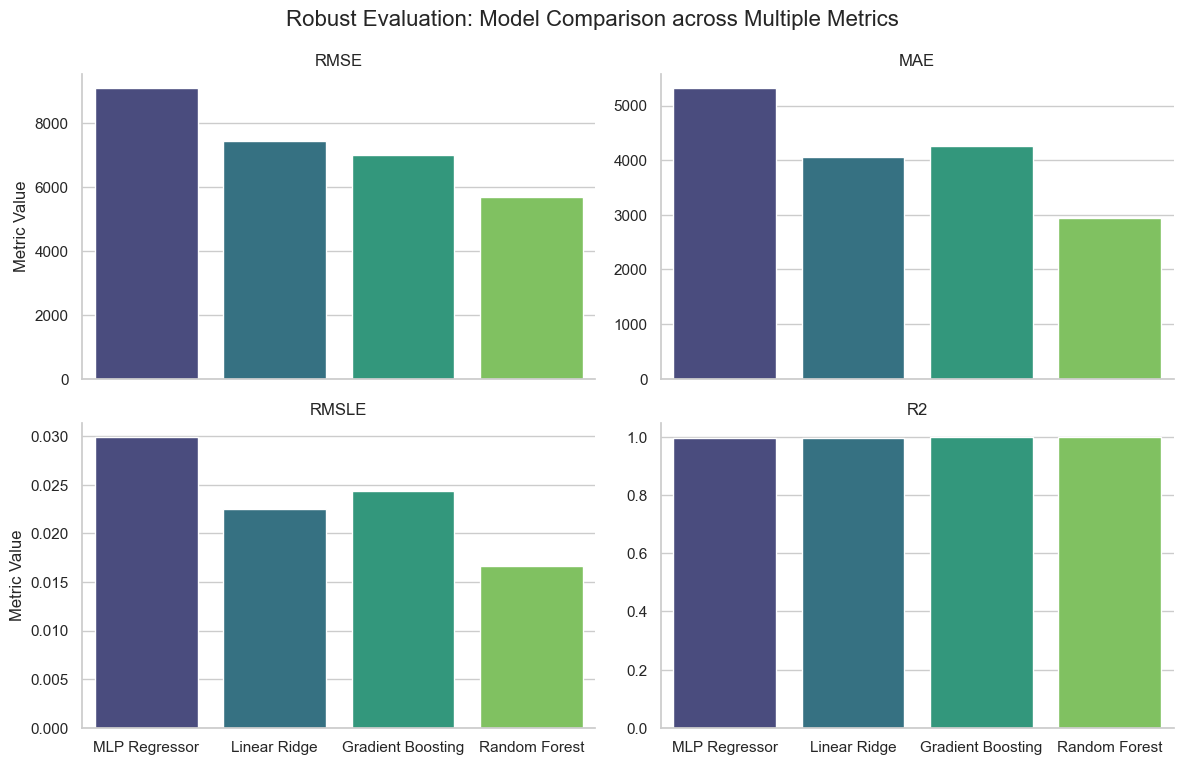

In [74]:

# 1. Collect metrics for both models
mlp_metrics = robust_evaluate(y_val, mlp_val_preds, "MLP Regressor")
ridge_metrics = robust_evaluate(y_val, ridge_val_preds, "Linear Ridge")
gb_metrics = robust_evaluate(y_val, gb_val_preds, "Gradient Boosting")
rf_metrics = robust_evaluate(y_val, rf_val_preds, "Random Forest")

# 2. Combine into one 'Plotting DataFrame'
comparison_df = pd.concat([mlp_metrics, ridge_metrics, gb_metrics, rf_metrics], ignore_index=True)

# 3. Melt the data so Seaborn can handle it (Long Format)
# We exclude 'R2' because it's on a 0-1 scale and would be invisible next to RMSE
plot_data = comparison_df.melt(id_vars="Model", value_vars=["RMSE", "MAE", "RMSLE", "R2"])

# 4. Create Faceted Bar Charts
g = sns.FacetGrid(plot_data, col="variable", hue="Model", 
                  col_wrap=2, height=4, aspect=1.5, sharey=False)

g.map(sns.barplot, "Model", "value", order=["MLP Regressor", "Linear Ridge", "Gradient Boosting", "Random Forest"], palette="viridis")

# Add titles and clean up
g.set_titles("{col_name}")
g.set_axis_labels("", "Metric Value")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Robust Evaluation: Model Comparison across Multiple Metrics", fontsize=16)

plt.show()

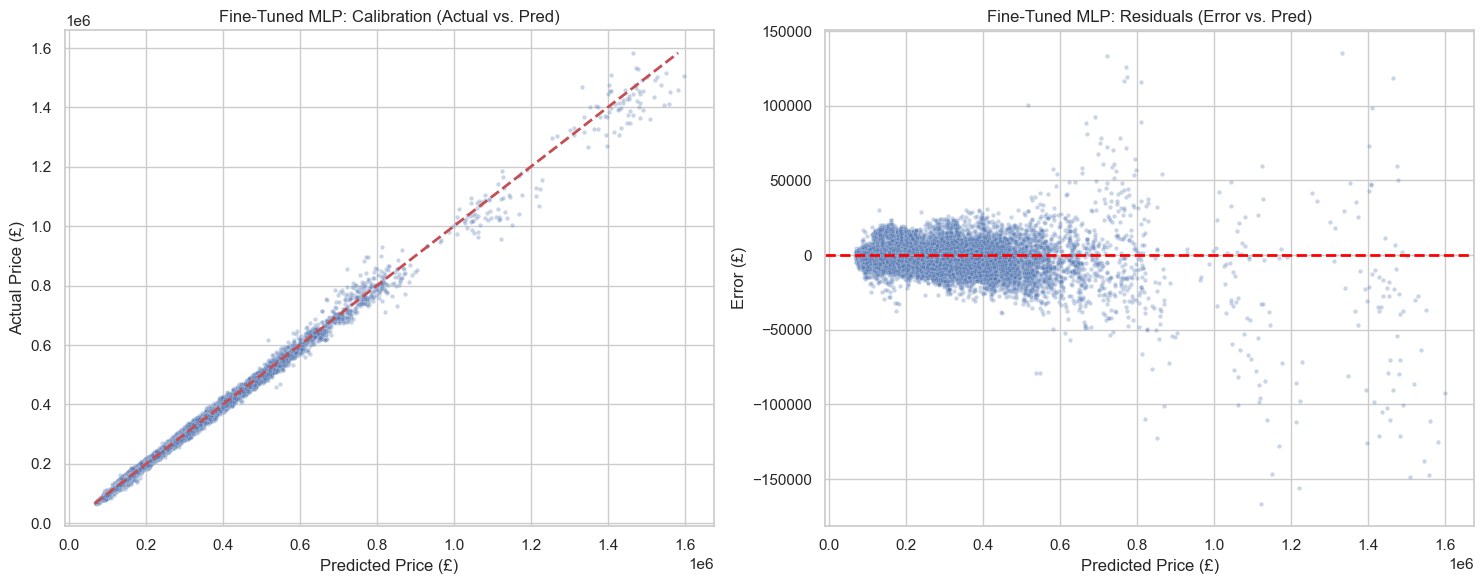

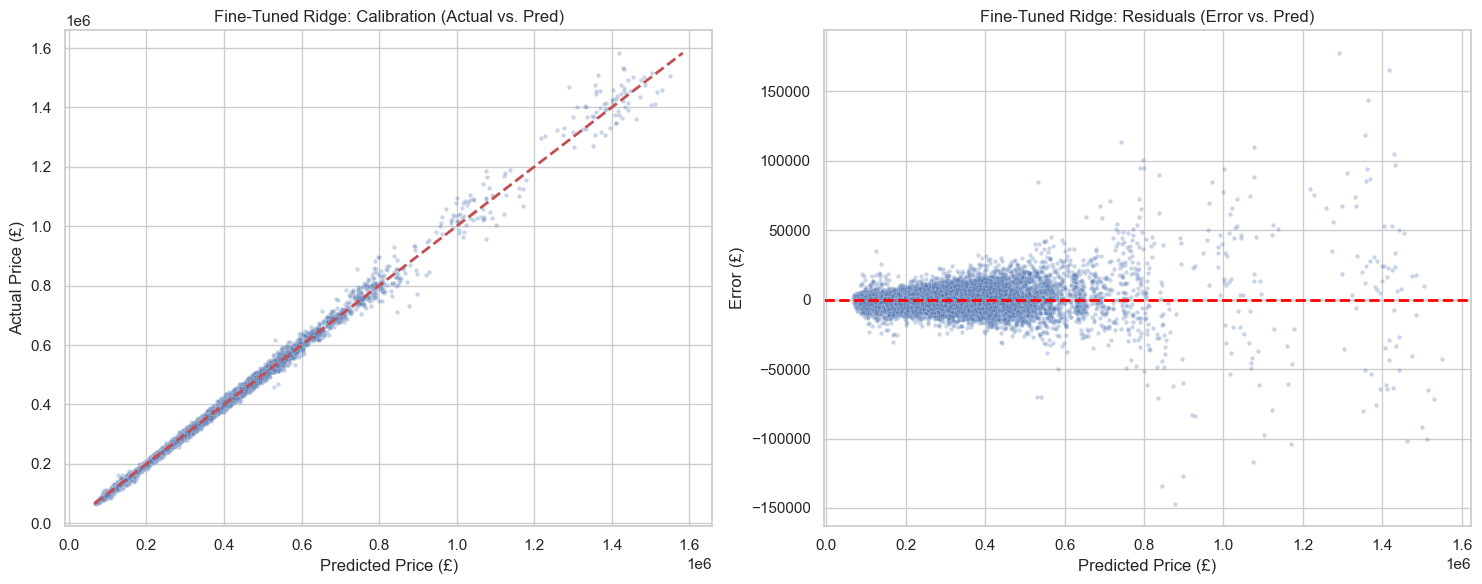

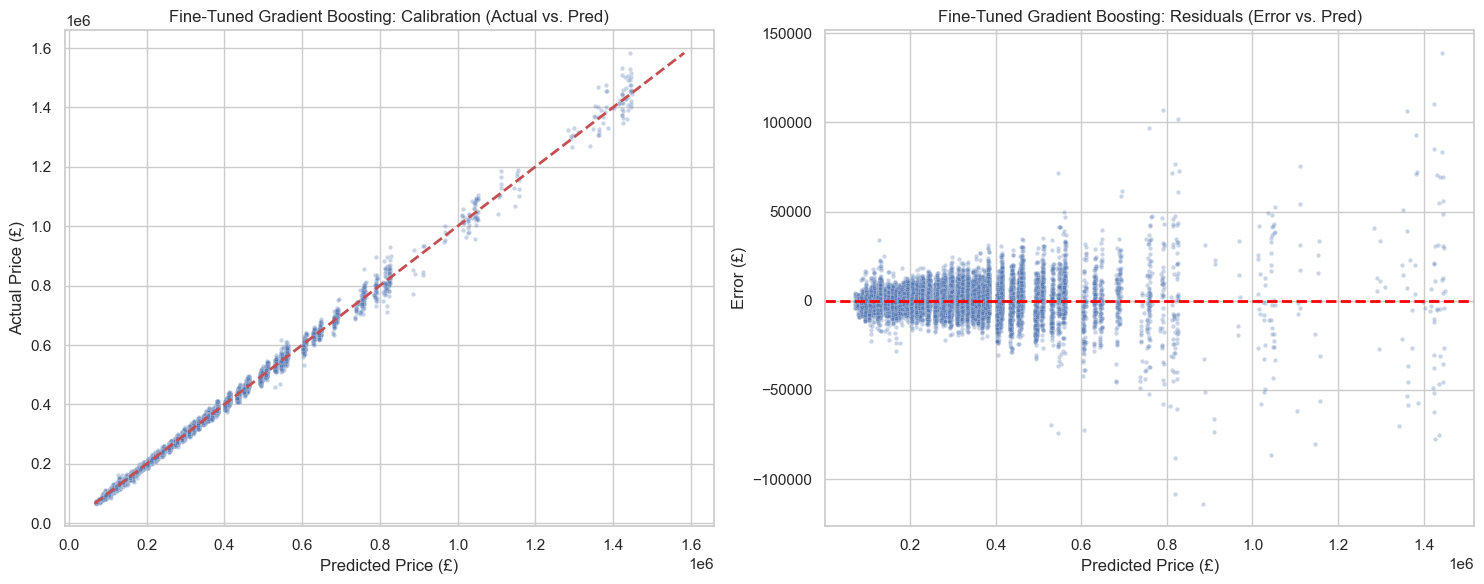

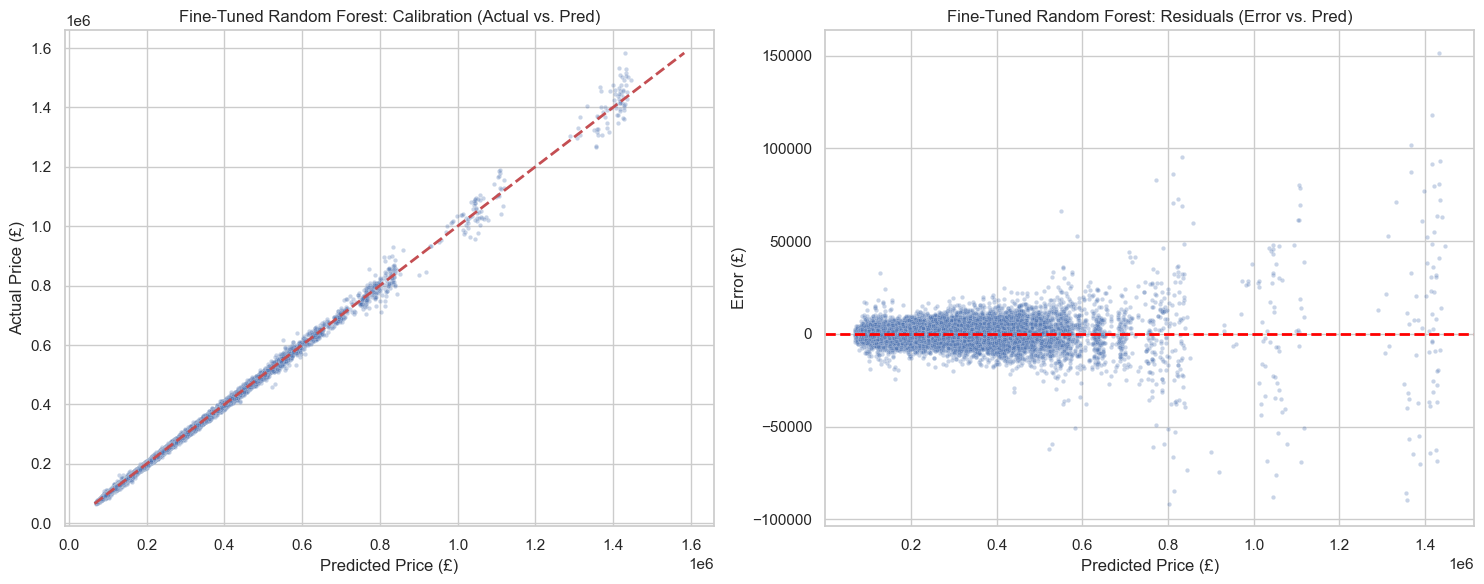

In [61]:
def plot_diagnostics(y_true, y_pred, model_name):
    residuals = y_true - y_pred
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # Calibration Plot (Actual vs Predicted)
    sns.scatterplot(x=y_pred, y=y_true, alpha=0.3, ax=ax[0], s=10)
    ax[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax[0].set_title(f"{model_name}: Calibration (Actual vs. Pred)")
    ax[0].set_xlabel("Predicted Price (£)")
    ax[0].set_ylabel("Actual Price (£)")

    # Residual Plot (Check for Heteroscedasticity / Failure Modes)
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, ax=ax[1], s=10)
    ax[1].axhline(0, color='red', linestyle='--', lw=2)
    ax[1].set_title(f"{model_name}: Residuals (Error vs. Pred)")
    ax[1].set_xlabel("Predicted Price (£)")
    ax[1].set_ylabel("Error (£)")
    
    plt.tight_layout()

# Plot for the MLP
plot_diagnostics(y_val, mlp_val_preds, "Fine-Tuned MLP")
plt.show()

# Plot for the Ridge
plot_diagnostics(y_val, ridge_val_preds, "Fine-Tuned Ridge")
plt.show()

# Plot for the Gradient Boosting
plot_diagnostics(y_val, gb_val_preds, "Fine-Tuned Gradient Boosting")
plt.show()

# Plot for the Random Forest
plot_diagnostics(y_val, rf_val_preds, "Fine-Tuned Random Forest")
plt.show()

In [62]:
def failure_mode_analysis(df_test, y_true, y_pred):
    analysis_df = df_test.copy()
    analysis_df['Error'] = y_true - y_pred
    analysis_df['AbsError'] = analysis_df['Error'].abs()
    analysis_df['PctError'] = (analysis_df['AbsError'] / y_true) * 100

    # Failure Mode A: Error by Price Tier
    analysis_df['PriceTier'] = pd.qcut(y_true, q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
    tier_errors = analysis_df.groupby('PriceTier')['PctError'].mean()

    # Failure Mode B: Top 10 Worst Predictions
    worst_fails = analysis_df.sort_values('AbsError', ascending=False).head(10)

    # Failure Mode C: Regional Performance
    reg_errors = analysis_df.groupby('RegionName')['PctError'].mean().sort_values(ascending=False)

    return tier_errors, worst_fails, reg_errors



/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3663493327.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_errors = analysis_df.groupby('PriceTier')['PctError'].mean()
/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3130109204.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_errors.index, y=tier_errors.values, ax=ax[0], palette="Reds_r")
/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3130109204.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

 

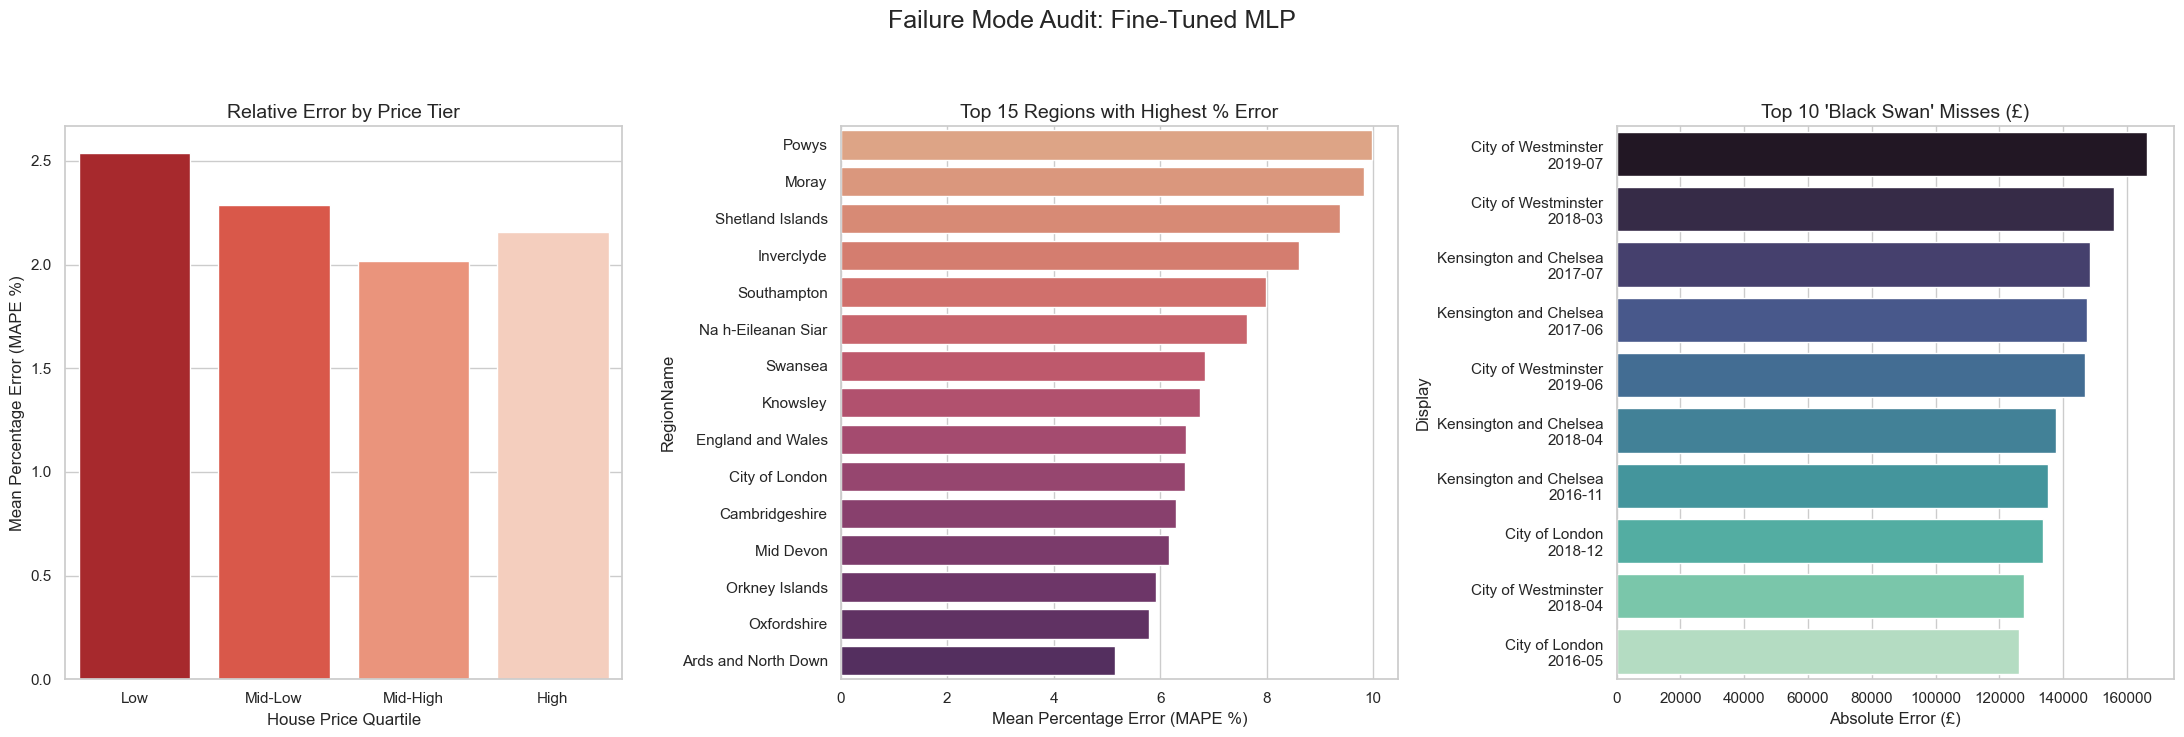

/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3663493327.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_errors = analysis_df.groupby('PriceTier')['PctError'].mean()
/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3130109204.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_errors.index, y=tier_errors.values, ax=ax[0], palette="Reds_r")
/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3130109204.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

 

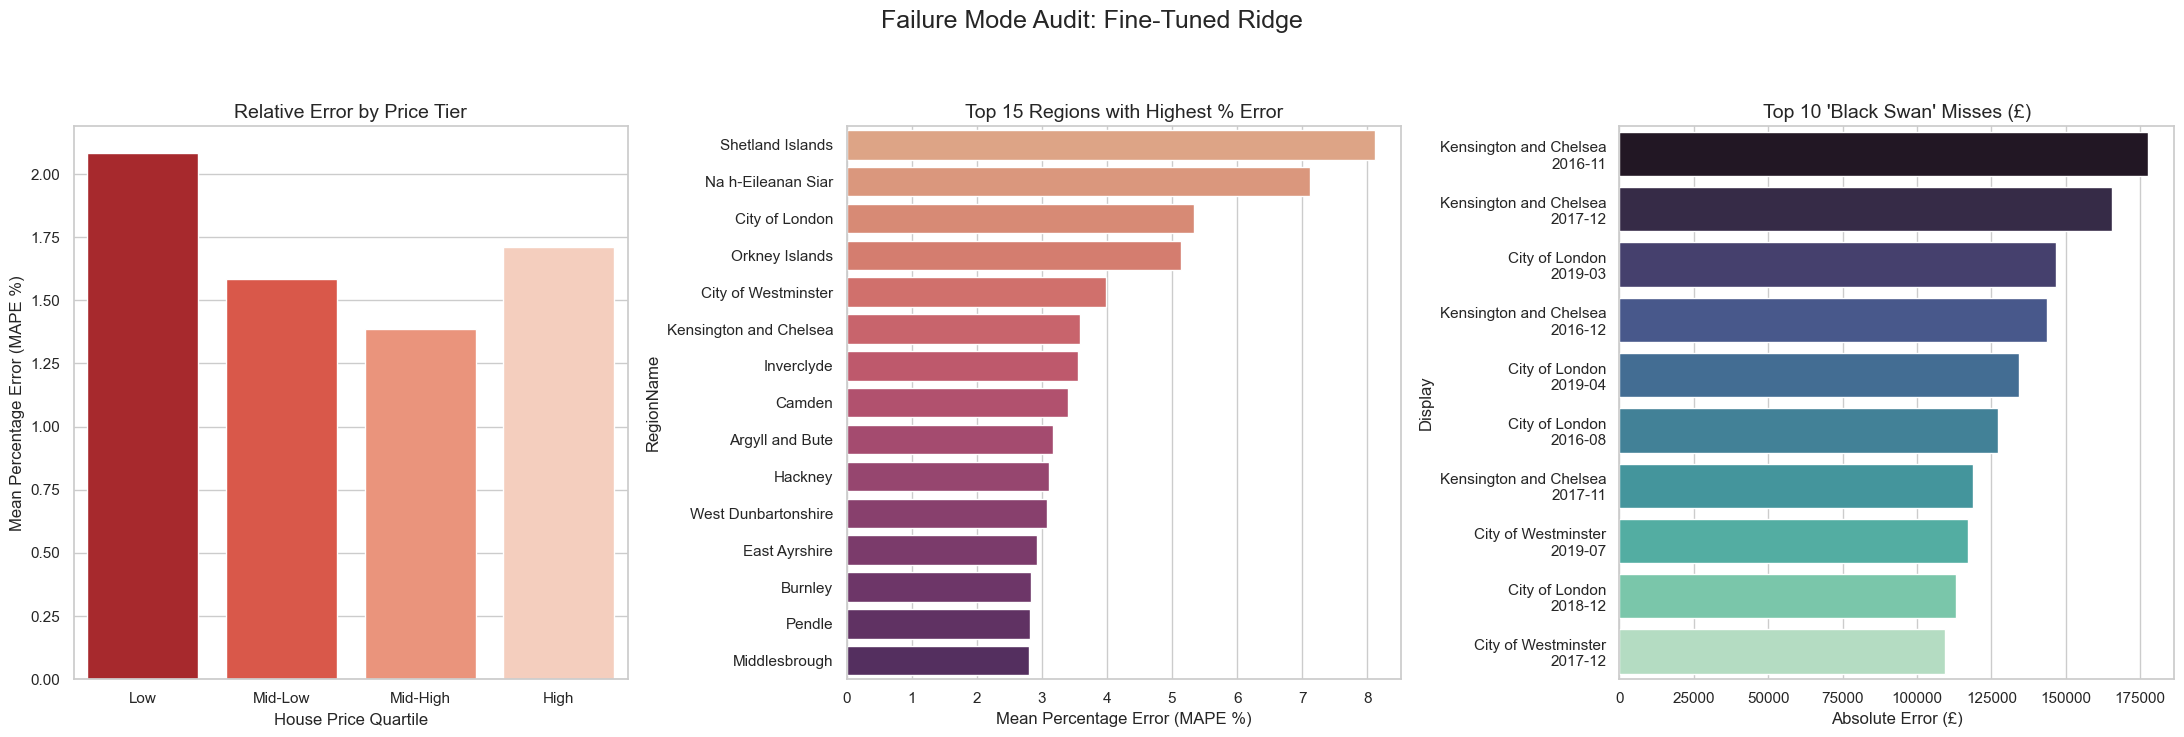

/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3663493327.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_errors = analysis_df.groupby('PriceTier')['PctError'].mean()
/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3130109204.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_errors.index, y=tier_errors.values, ax=ax[0], palette="Reds_r")
/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3130109204.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

 

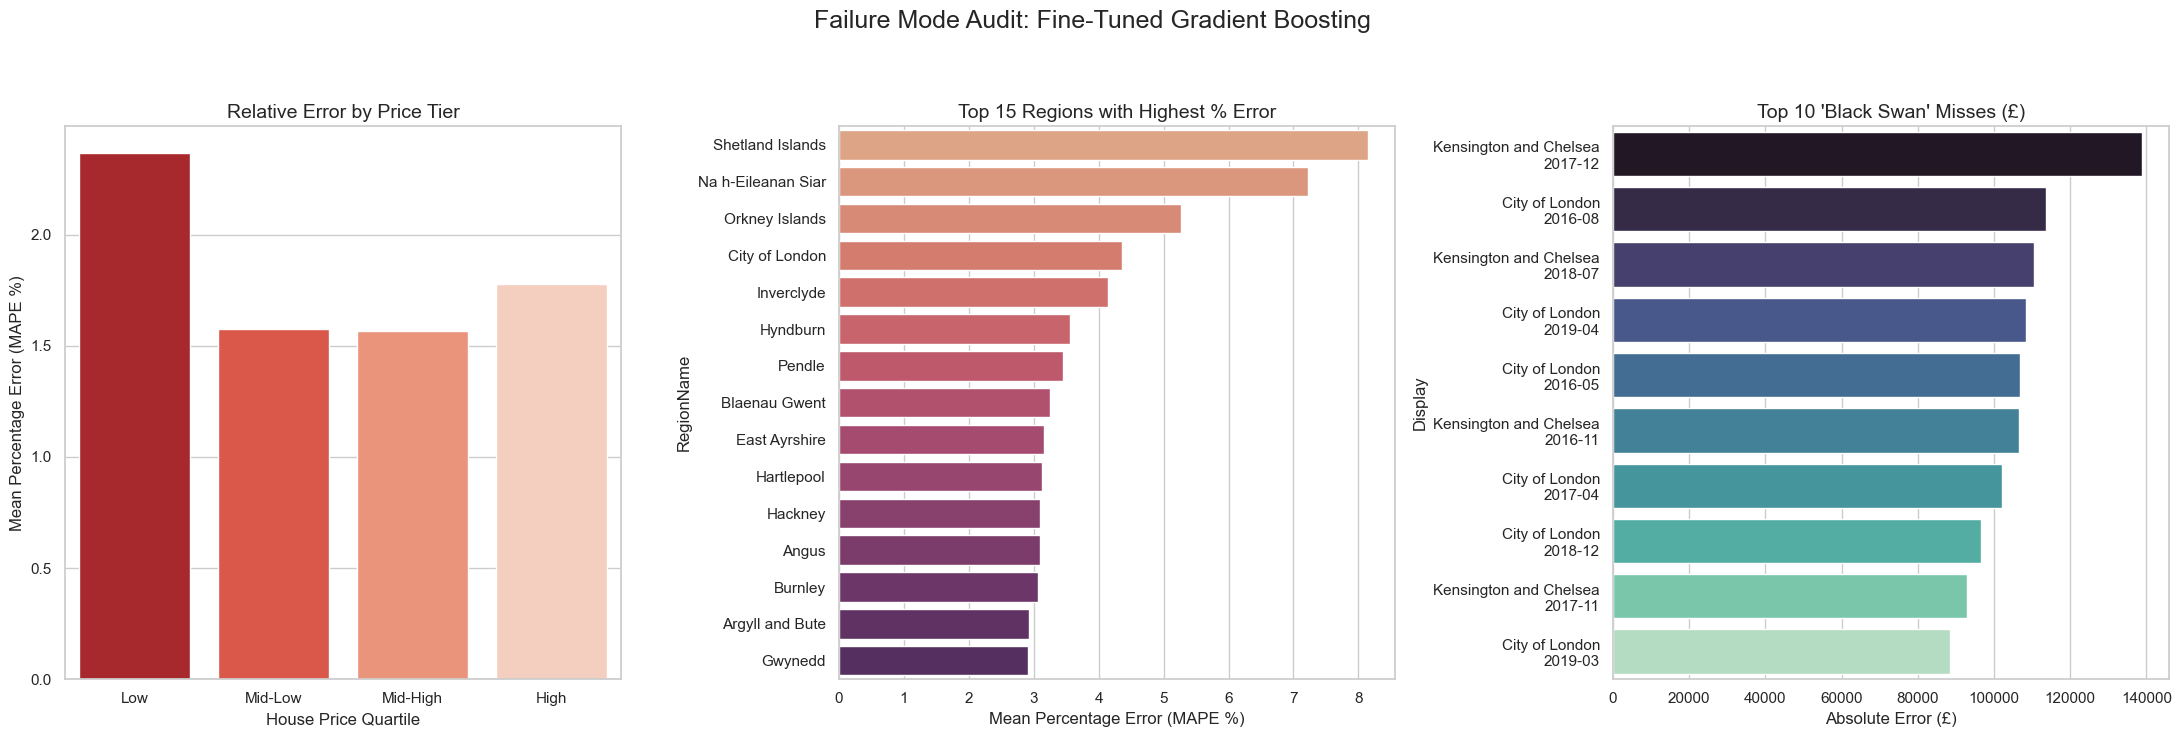

/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3663493327.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_errors = analysis_df.groupby('PriceTier')['PctError'].mean()
/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3130109204.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_errors.index, y=tier_errors.values, ax=ax[0], palette="Reds_r")
/var/folders/bp/w2sdzhg913qdgzdvy7_0mmy00000gn/T/ipykernel_6006/3130109204.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

 

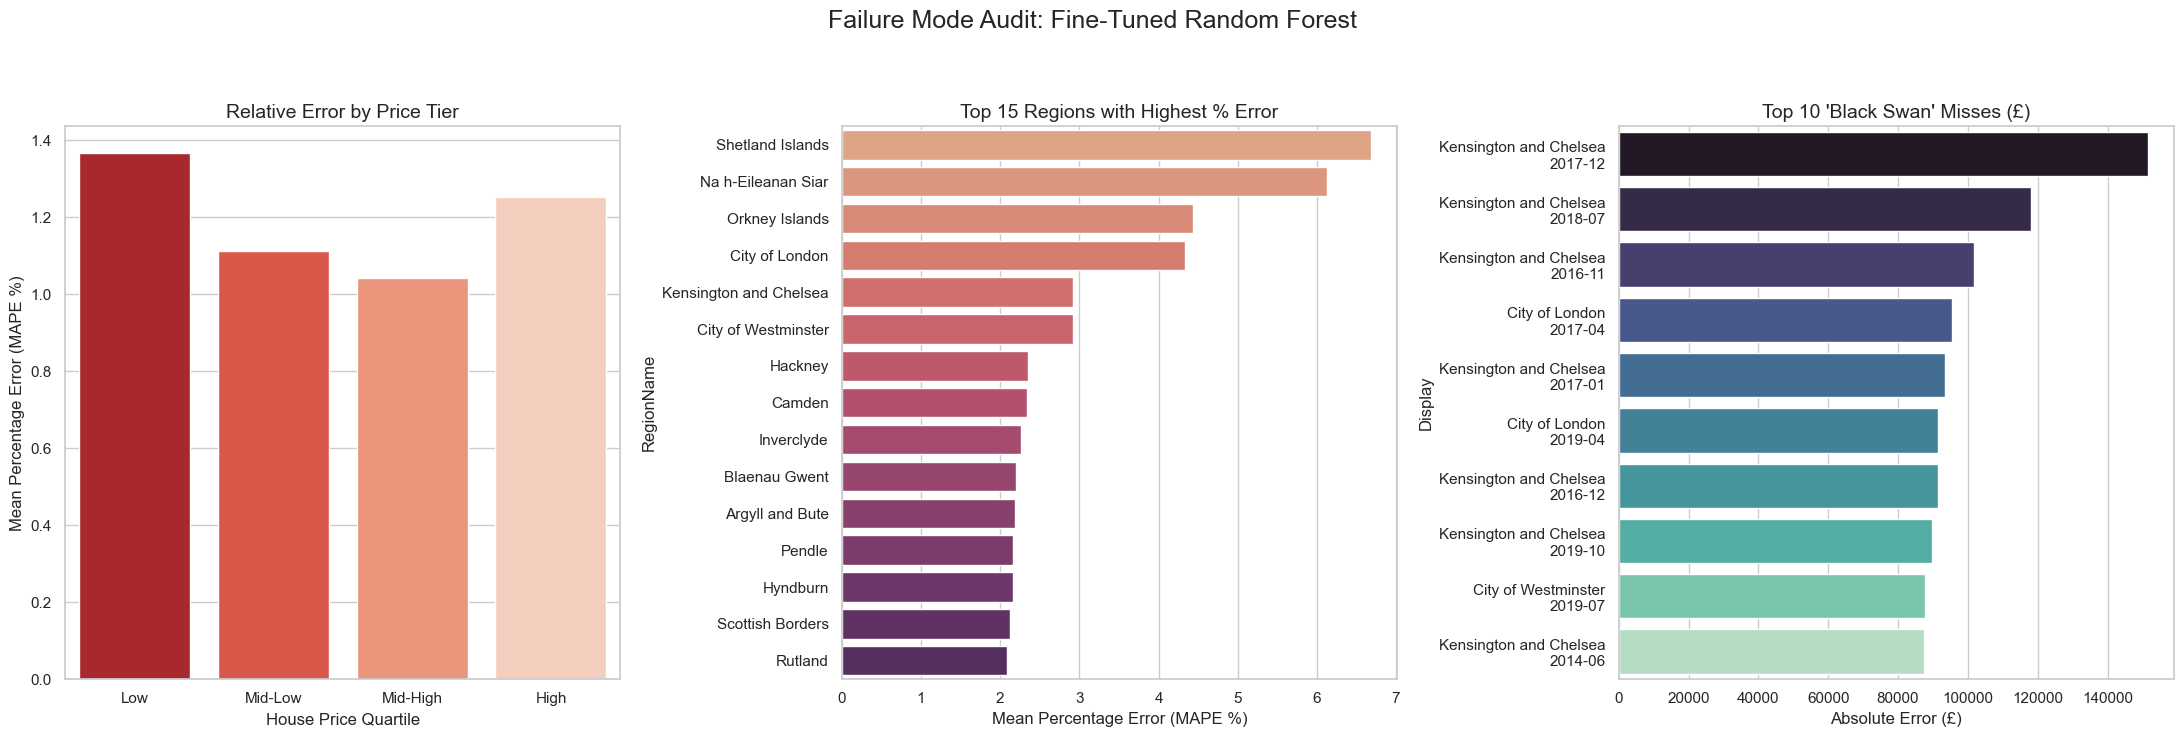

In [64]:
def plot_failure_modes(tier_errors, worst_fails, reg_errors, model_name):
    fig, ax = plt.subplots(1, 3, figsize=(22, 7))
    fig.suptitle(f"Failure Mode Audit: {model_name}", fontsize=18, y=1.05)

    # Plot A: Error by Price Tier (Percentage Error)
    # This reveals if the 'Trumpet' is a percentage issue or just a scale issue
    sns.barplot(x=tier_errors.index, y=tier_errors.values, ax=ax[0], palette="Reds_r")
    ax[0].set_title("Relative Error by Price Tier", fontsize=14)
    ax[0].set_ylabel("Mean Percentage Error (MAPE %)")
    ax[0].set_xlabel("House Price Quartile")

    # Plot B: Regional Performance (Top 15 Worst Regions)
    # This shows geographic bias (e.g., is the model failing in London?)
    top_reg_errors = reg_errors.head(15)
    sns.barplot(x=top_reg_errors.values, y=top_reg_errors.index, ax=ax[1], palette="flare")
    ax[1].set_title("Top 15 Regions with Highest % Error", fontsize=14)
    ax[1].set_xlabel("Mean Percentage Error (MAPE %)")

    # Plot C: Worst 10 Individual Predictions (Absolute Error)
    # This helps identify data outliers or 'Black Swan' events
    worst_fails['Display'] = worst_fails['RegionName'] + "\n" + worst_fails['Date'].dt.strftime('%Y-%m')
    sns.barplot(x=worst_fails['AbsError'], y=worst_fails['Display'], ax=ax[2], palette="mako")
    ax[2].set_title("Top 10 'Black Swan' Misses (£)", fontsize=14)
    ax[2].set_xlabel("Absolute Error (£)")

    plt.tight_layout()
    plt.show()



# Now you can run your failure mode analysis without the NameError
tier_err, worst, reg_err = failure_mode_analysis(val_df, y_val, mlp_val_preds)
plot_failure_modes(tier_err, worst, reg_err, "Fine-Tuned MLP")

tier_err, worst, reg_err = failure_mode_analysis(val_df, y_val, ridge_val_preds)
plot_failure_modes(tier_err, worst, reg_err, "Fine-Tuned Ridge")

tier_err, worst, reg_err = failure_mode_analysis(val_df, y_val, gb_val_preds)
plot_failure_modes(tier_err, worst, reg_err, "Fine-Tuned Gradient Boosting")

tier_err, worst, reg_err = failure_mode_analysis(val_df, y_val, rf_val_preds)
plot_failure_modes(tier_err, worst, reg_err, "Fine-Tuned Random Forest")

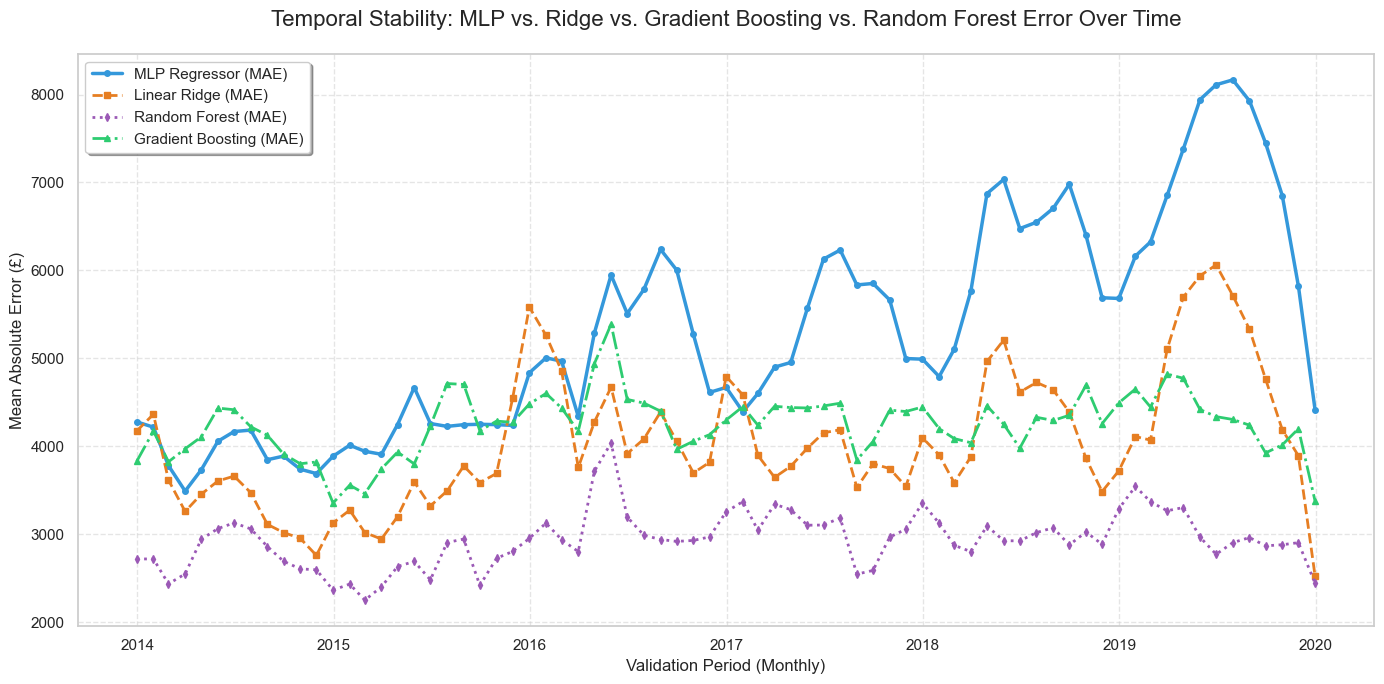

In [75]:
# 1. Create a combined error DataFrame for the Validation period
# We use val_df['Date'] as the shared timeline
stability_df = pd.DataFrame({
    'Date': val_df['Date'],
    'MLP_AE': np.abs(y_val - mlp_val_preds),   # Absolute Error for MLP
    'Ridge_AE': np.abs(y_val - ridge_val_preds), # Absolute Error for Ridge
    'GB_AE': np.abs(y_val - gb_val_preds),      # Absolute Error for Gradient Boosting
    'RF_AE': np.abs(y_val - rf_val_preds)      # Absolute Error for Random Forest
})

# 2. Resample to Monthly Mean Absolute Error (MAE)
# 'ME' groups by month-end to smooth out the daily regional noise
monthly_stability = stability_df.groupby(pd.Grouper(key='Date', freq='ME')).mean()

# 3. Create the Visualization
plt.figure(figsize=(14, 7))

# Plot MLP Performance
plt.plot(monthly_stability.index, monthly_stability['MLP_AE'], 
         label='MLP Regressor (MAE)', color='#3498db', linewidth=2.5, marker='o', markersize=4)

# Plot Ridge Performance
plt.plot(monthly_stability.index, monthly_stability['Ridge_AE'], 
         label='Linear Ridge (MAE)', color='#e67e22', linewidth=2, linestyle='--', marker='s', markersize=4)

# Plot Random Forest Performance
plt.plot(monthly_stability.index, monthly_stability['RF_AE'], 
         label='Random Forest (MAE)', color='#9b59b6', linewidth=2, linestyle=':', marker='d', markersize=4)

# Plot Gradient Boosting Performance
plt.plot(monthly_stability.index, monthly_stability['GB_AE'], 
         label='Gradient Boosting (MAE)', color='#2ecc71', linewidth=2, linestyle='-.', marker='^', markersize=4)

# 4. Final Formatting
plt.title("Temporal Stability: MLP vs. Ridge vs. Gradient Boosting vs. Random Forest Error Over Time", fontsize=16, pad=20)
plt.ylabel("Mean Absolute Error (£)", fontsize=12)
plt.xlabel("Validation Period (Monthly)", fontsize=12)
plt.grid(True, which='major', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

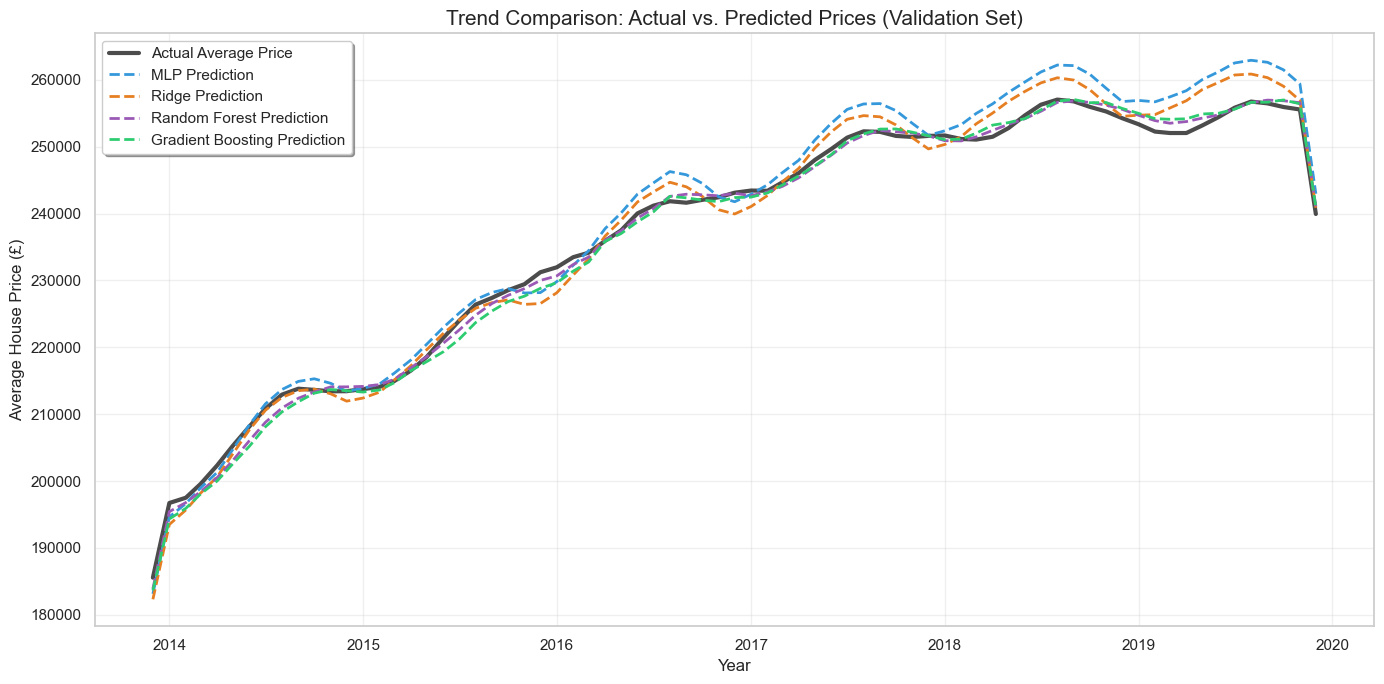

In [68]:
# 1. Combine data and group by Date to get the average trend
# This smooths out the regional noise to show the overall model performance
ts_plot_df = pd.DataFrame({
    'Date': val_df['Date'],
    'Actual': y_val,
    'MLP_Predicted': mlp_val_preds,
    'Ridge_Predicted': ridge_val_preds,
    'GB_Predicted': gb_val_preds,
    'RF_Predicted': rf_val_preds
}).groupby('Date').mean().reset_index()

# 2. Create the line plot
plt.figure(figsize=(14, 7))

# Plot Actual Values
plt.plot(ts_plot_df['Date'], ts_plot_df['Actual'], 
         label='Actual Average Price', color='black', linewidth=3, alpha=0.7)

# Plot MLP Predictions
plt.plot(ts_plot_df['Date'], ts_plot_df['MLP_Predicted'], 
         label='MLP Prediction', color='#3498db', linestyle='--', linewidth=2)

# Plot Ridge Predictions
plt.plot(ts_plot_df['Date'], ts_plot_df['Ridge_Predicted'], 
         label='Ridge Prediction', color='#e67e22', linestyle='--', linewidth=2)

# Plot Random Forest Predictions
plt.plot(ts_plot_df['Date'], ts_plot_df['RF_Predicted'],    
         label='Random Forest Prediction', color='#9b59b6', linestyle='--', linewidth=2)

# Plot Gradient Boosting Predictions
plt.plot(ts_plot_df['Date'], ts_plot_df['GB_Predicted'], 
         label='Gradient Boosting Prediction', color='#2ecc71', linestyle='--', linewidth=2)

# 3. Final Formatting
plt.title("Trend Comparison: Actual vs. Predicted Prices (Validation Set)", fontsize=15)
plt.ylabel("Average House Price (£)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, shadow=True, fontsize=11)

plt.tight_layout()
plt.show()

# **6. Present the final solution**

In [76]:
# 1. Re-fit the winning model on the combined Train + Val data
# This gives the model the 'most recent' history before hitting the Test set
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

winning_model = rf_search.best_estimator_
winning_model.fit(X_final_train, y_final_train)

# 2. Predict on the Test Set (The 'Final Exam')
y_test_preds = winning_model.predict(X_test)

# 3. Calculate Final Performance Metrics
final_metrics = {
    "MAE (£)": mean_absolute_error(y_test, y_test_preds),
    "RMSE (£)": np.sqrt(mean_squared_error(y_test, y_test_preds)),
    "RMSLE": np.sqrt(mean_squared_log_error(y_test, y_test_preds)),
    "R2 Score": r2_score(y_test, y_test_preds)
}

# Display results
results_final = pd.DataFrame([final_metrics], index=["Random forest (Test Set)"])
print("--- FINAL PROJECT RESULTS (TEST SET: 2020-2025) ---")
display(results_final.round(4))

--- FINAL PROJECT RESULTS (TEST SET: 2020-2025) ---


,MAE (£),RMSE (£),RMSLE,R2 Score
Random forest (Test Set),5161.9261,9835.6247,0.0229,0.9958
